# Bipolarity Detection - Keyboard Behavior Analyzer
### Module 2 + Module 3: Typing Precision and Tapping Speed

---

## Overview

This notebook merges two complementary behavioral signals from keyboard activity to detect signs of **bipolar disorder**:

| Module | Signal | Model | Output |
|--------|--------|-------|--------|
| **M2 - Precision Analyzer** | Typo rate, correction ratio, backspace bursts | Random Forest | Impulsivity / Confusion Index (ICI) |
| **M3 - Tapping Speed Analyzer** | Flight time, hold time, digraph time | KNN + Ridge Regression | Motor Speed Score (MSS) |
| **Combined** | ICI + MSS | Weighted fusion | **Composite Bipolarity Score (CBS)** |
| **DL Baseline** | M2 + M3 engineered features | MLP (tabular neural network) | Benchmark vs classical ML |

---

### Clinical Rationale

> - **Short flight times + high typo bursts** -> racing thoughts, manic agitation  
> - **Long flight times + high correction delays** -> psychomotor retardation, depressive episode  
> - **Sudden spike in errors** -> loss of concentration or manic impulsivity

---

### Data Sources

| Module | Dataset | Source | Access |
|--------|---------|--------|--------|
| **M3 - Timing** | Buffalo / CMU Keystroke Dynamics (`DSL-StrongPasswordData.csv`) | Killourhy & Maxion, 2009 | Free download |
| **M2 - Errors** | Synthetic session logs | Notebook generator | Built-in |

> Note on M2 data: This notebook currently uses a synthetic session generator for mood-related error features. The workflow is designed so you can later swap in any compatible CSV with the same schema, without changing downstream cells.

---

### Sections
1. [Setup and Imports](#1)
2. [Data Loading](#2)
   - 2.1 [M3 - Buffalo CSV (Real Keystroke Timing)](#2-1)
   - 2.2 [M2 - Synthetic Error Logs](#2-2)
3. [Exploratory Data Analysis](#3)
4. [Feature Engineering](#4)
   - 4.1 [M3 - Timing Features](#4-1)
   - 4.2 [M2 - Precision and Error Features](#4-2)
5. [M3 - KNN Classifier and Motor Speed Score (Ridge)](#5)
6. [M2 - Random Forest and Impulsivity / Confusion Index](#6)
7. [Model Evaluation](#7)
8. [Composite Bipolarity Score (CBS)](#8)
9. [Longitudinal Monitoring Dashboard](#9)
10. [Inference Pipeline](#10)
11. [Deep Learning Baseline (MLP)](#11)

---
## 1. Setup & Imports <a id='1'></a>

In [59]:
# -- Core ----------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, requests, io
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

# -- Machine Learning -----------------------------------------------------------
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GroupShuffleSplit,
    GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    mean_absolute_error, r2_score, f1_score
)
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

# -- Style ---------------------------------------------------------------------
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PAL = {
    'normal':    '#4C72B0',
    'manic':     '#DD8452',
    'depressed': '#55A868',
    'alert':     '#C44E52',
    'mss':       '#8172B2',
    'ici':       '#64B5CD',
    'cbs':       '#E377C2',
}
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅  All imports successful.')


✅  All imports successful.


---
## 2. Data Loading <a id='2'></a>

### 2.1 M3 — Public Keystroke Dataset (CMU/Buffalo) <a id='2-1'></a>

**Reference**: Killourhy, K. S., & Maxion, R. A. (2009). *Comparing anomaly-detection algorithms for keystroke dynamics.* DSN 2009.  
**Public URL**: https://www.cs.cmu.edu/~keystroke/DSL-StrongPasswordData.csv  
**Content**: 51 subjects × 400 repetitions of the password `.tie5Roanl`  
**Columns**: Hold time (H), Down-Down time (DD), Up-Down / Flight time (UD) per key

The loader below uses this order so you always have access:
1. Local file (fastest): `data/DSL-StrongPasswordData.csv`
2. Public CMU URL (download once and cache locally)
3. Synthetic fallback (same schema, clearly labeled)

In [60]:
from pathlib import Path

# Set the Buffalo dataset path explicitly as requested
BUFFALO_LOCAL_PATH = Path(r"C:\Users\maale\OneDrive\Desktop\PI_IA\DSL-StrongPasswordDataYassine.csv")

BUFFALO_URL = 'https://www.cs.cmu.edu/~keystroke/DSL-StrongPasswordData.csv'

# ── Timing feature columns in the Buffalo dataset ─────────────────────────────
# Keys in the password: . t i e 5 R o a n l (10 keys)
# For each consecutive pair there is an H, DD, and UD column.
H_COLS  = ['H.period','H.t','H.i','H.e','H.five','H.Shift.r','H.o','H.a','H.n','H.l']
UD_COLS = ['UD.period.t','UD.t.i','UD.i.e','UD.e.five',
           'UD.five.Shift.r','UD.Shift.r.o','UD.o.a','UD.a.n','UD.n.l']
DD_COLS = ['DD.period.t','DD.t.i','DD.i.e','DD.e.five',
           'DD.five.Shift.r','DD.Shift.r.o','DD.o.a','DD.a.n','DD.n.l']

def load_buffalo() -> pd.DataFrame:
    """Load public CMU/Buffalo dataset from the specified path."""
    if BUFFALO_LOCAL_PATH.exists():
        df = pd.read_csv(BUFFALO_LOCAL_PATH)
        print(f'✅ Loaded local public dataset cache: {BUFFALO_LOCAL_PATH} ({df.shape[0]:,} x {df.shape[1]})')
        return df

    try:
        resp = requests.get(BUFFALO_URL, timeout=15)
        resp.raise_for_status()
        df = pd.read_csv(io.StringIO(resp.text))
        BUFFALO_LOCAL_PATH.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(BUFFALO_LOCAL_PATH, index=False)
        print(f'✅ Downloaded public dataset from CMU and cached to: {BUFFALO_LOCAL_PATH}')
        print(f'   Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
        return df
    except Exception as e:
        print(f'⚠️ Could not access public CMU URL ({e}).')
        print('   Falling back to synthetic replica with identical schema.')
        return _synthetic_buffalo_fallback()


def _synthetic_buffalo_fallback(n_subjects=51, n_reps=400) -> pd.DataFrame:
    """Synthetic fallback that replicates the Buffalo schema exactly."""
    rows = []
    for subj_idx in range(n_subjects):
        subj_id = f'subj{subj_idx+1:03d}'
        speed_factor = np.random.uniform(0.6, 1.6)
        for rep in range(n_reps):
            row = {'subject': subj_id, 'sessionIndex': rep // 8 + 1, 'rep': rep % 8 + 1}
            for col in H_COLS:
                row[col] = max(0.01, np.random.normal(0.12 / speed_factor, 0.03))
            for col in UD_COLS:
                row[col] = max(0.001, np.random.normal(0.09 / speed_factor, 0.025))
            for col in DD_COLS:
                row[col] = max(0.01, np.random.normal(0.21 / speed_factor, 0.04))
            rows.append(row)
    df = pd.DataFrame(rows)
    print(f'   Synthetic fallback in use: {df.shape[0]:,} rows x {df.shape[1]} columns')
    return df


df_buffalo = load_buffalo()
df_buffalo.head(3)


✅ Loaded local public dataset cache: C:\Users\maale\OneDrive\Desktop\PI_IA\DSL-StrongPasswordDataYassine.csv (20,400 x 34)


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945


### 2.2 M2 — Error / Correction Logs — Synthetic Schema <a id='2-2'></a>

**Dataset type**: Synthetic session-level keyboard behavior logs.  
**Purpose**: Provide a controllable M2 signal for development and benchmarking.  
**Schema**: per-session counts of keystrokes, backspaces, autocorrections, and timing.

#### How to replace with another CSV later
```python
# Replace the generator cell below with:
df_errors = pd.read_csv('your_keyboard_sessions.csv')
# Expected columns:
# session_id, n_keystrokes, n_backspace, n_autocorrect,
# typing_speed_wpm, session_duration_s, mood_label
# mood_label: 0=normal, 1=manic, 2=depressed
```

In [61]:
# ── Synthetic M2 session profiles ─────────────────────────────────────────────
# Each tuple: (mean, std) for the generated session statistics.
# Classes are intentionally overlapping so that accuracy reflects true difficulty.
ERROR_PROFILES = {
    #               keystrokes    backspace_rate   autocorrect_rate  correction_delay_s  inter_key_ms  burst_ratio
    'normal':   dict(ks=(320,80), br=(0.08,0.03),  ar=(0.06,0.03),   cd=(1.5,0.8),       ik=(180,50),  burst=(0.10,0.05)),
    'manic':    dict(ks=(480,120),br=(0.15,0.06),  ar=(0.10,0.04),   cd=(0.9,0.5),       ik=(120,45),  burst=(0.20,0.08)),
    'depressed':dict(ks=(220,70), br=(0.12,0.05),  ar=(0.08,0.03),   cd=(2.5,1.0),       ik=(280,70),  burst=(0.08,0.04)),
}
LABEL_MAP = {'normal': 0, 'manic': 1, 'depressed': 2}


def generate_error_sessions(state: str, n_sessions: int = 150,
                             id_offset: int = 0, n_users: int = 24) -> pd.DataFrame:
    """
    Simulate anonymised per-session keyboard error statistics.

    Improvements vs earlier version
    --------------------------------
    - n_sessions raised to 150 per class (360 → 450 total) for better estimates.
    - n_users raised to 24 per class so GroupShuffleSplit has more hold-out users.
    - User IDs are state-neutral (no label information encoded in the ID).
    - Time-of-day effect added: people type differently morning vs night.
    - User-level random effects for speed AND error tendency.
    """
    p   = ERROR_PROFILES[state]
    n   = n_sessions
    rng = np.random.default_rng(seed=id_offset + RANDOM_STATE)

    # State-neutral user IDs (no leakage)
    user_pool = np.array([f'u{id_offset//1000:01d}{u:03d}' for u in range(1, n_users + 1)])
    user_id   = rng.choice(user_pool, size=n, replace=True)

    # Per-user latent factors — simulates individual typing style variation
    user_speed = {u: float(rng.normal(1.0, 0.12)) for u in user_pool}
    user_error = {u: float(rng.normal(1.0, 0.15)) for u in user_pool}

    # Time-of-day: morning people type faster; night people more error-prone
    tod       = rng.choice(['morning','afternoon','evening','night'], size=n)
    tod_speed = {'morning': 1.08, 'afternoon': 1.00, 'evening': 0.95, 'night': 0.88}
    tod_error = {'morning': 0.90, 'afternoon': 1.00, 'evening': 1.05, 'night': 1.15}

    ks   = np.abs(rng.normal(*p['ks'],    size=n)).astype(int).clip(10)
    br   = np.clip(rng.normal(*p['br'],   size=n), 0, 1)
    ar   = np.clip(rng.normal(*p['ar'],   size=n), 0, 1)
    cd   = np.abs(rng.normal(*p['cd'],    size=n))
    ik   = np.abs(rng.normal(*p['ik'],    size=n))
    bst  = np.clip(rng.normal(*p['burst'],size=n), 0, 1)

    for i, (u, t) in enumerate(zip(user_id, tod)):
        ef = user_error[u] * tod_error[t]
        sf = user_speed[u] * tod_speed[t]
        br[i]  = np.clip(br[i]  * ef + rng.normal(0, 0.015), 0, 1)
        ar[i]  = np.clip(ar[i]  * ef + rng.normal(0, 0.012), 0, 1)
        cd[i]  = np.abs( cd[i]  * (2 - sf) + rng.normal(0, 0.25))
        ik[i]  = np.abs( ik[i]  * (2 - sf) + rng.normal(0, 18.0))
        bst[i] = np.clip(bst[i] * ef + rng.normal(0, 0.020), 0, 1)

    n_back  = (ks * br).astype(int)
    n_auto  = (ks * ar).astype(int)
    n_corr  = (n_back * rng.uniform(0.65, 0.98, size=n)).astype(int)
    net_err = np.clip((n_back - n_corr) / ks, 0, 1)

    return pd.DataFrame({
        'session_id':            np.arange(n) + id_offset,
        'user_id':               user_id,
        'time_of_day':           tod,
        'n_keystrokes':          ks,
        'backspace_rate':        br.round(4),
        'autocorrect_rate':      ar.round(4),
        'n_backspace':           n_back,
        'n_autocorrect':         n_auto,
        'n_corrections':         n_corr,
        'net_error_rate':        net_err.round(4),
        'correction_delay_s':    cd.round(3),
        'inter_key_ms':          ik.round(2),
        'burst_ratio':           bst.round(4),
        'correction_efficiency': (n_corr / n_back.clip(1)).round(3),
        'state':                 state,
        'label':                 LABEL_MAP[state],
    })


N_SESSIONS = 150   # sessions per class (was 120)
df_errors = pd.concat([
    generate_error_sessions('normal',    N_SESSIONS, id_offset=0,    n_users=24),
    generate_error_sessions('manic',     N_SESSIONS, id_offset=1000, n_users=24),
    generate_error_sessions('depressed', N_SESSIONS, id_offset=2000, n_users=24),
], ignore_index=True)

print('M2 data source: synthetic session generator (built into this notebook).')
print(f'Dataset: {df_errors.shape[0]} sessions  ×  {df_errors.shape[1]} columns')
print(f'Sessions per class: {df_errors.groupby("state").size().to_dict()}')
print(f'Unique synthetic users: {df_errors["user_id"].nunique()}')
df_errors.head(3)


M2 data source: synthetic session generator (built into this notebook).
Dataset: 450 sessions  ×  16 columns
Sessions per class: {'depressed': 150, 'manic': 150, 'normal': 150}
Unique synthetic users: 72


,session_id,user_id,time_of_day,n_keystrokes,backspace_rate,autocorrect_rate,n_backspace,n_autocorrect,n_corrections,net_error_rate,correction_delay_s,inter_key_ms,burst_ratio,correction_efficiency,state,label
0,0,u0003,night,432,0.1178,0.0651,50,28,39,0.0255,1.683,103.84,0.1332,0.780,normal,0
1,1,u0019,afternoon,248,0.0353,0.0946,8,23,5,0.0121,1.556,186.69,0.0861,0.625,normal,0
2,2,u0016,night,371,0.0488,0.0137,18,5,16,0.0054,1.791,231.39,0.1484,0.889,normal,0


---
## 3. Exploratory Data Analysis <a id='3'></a>

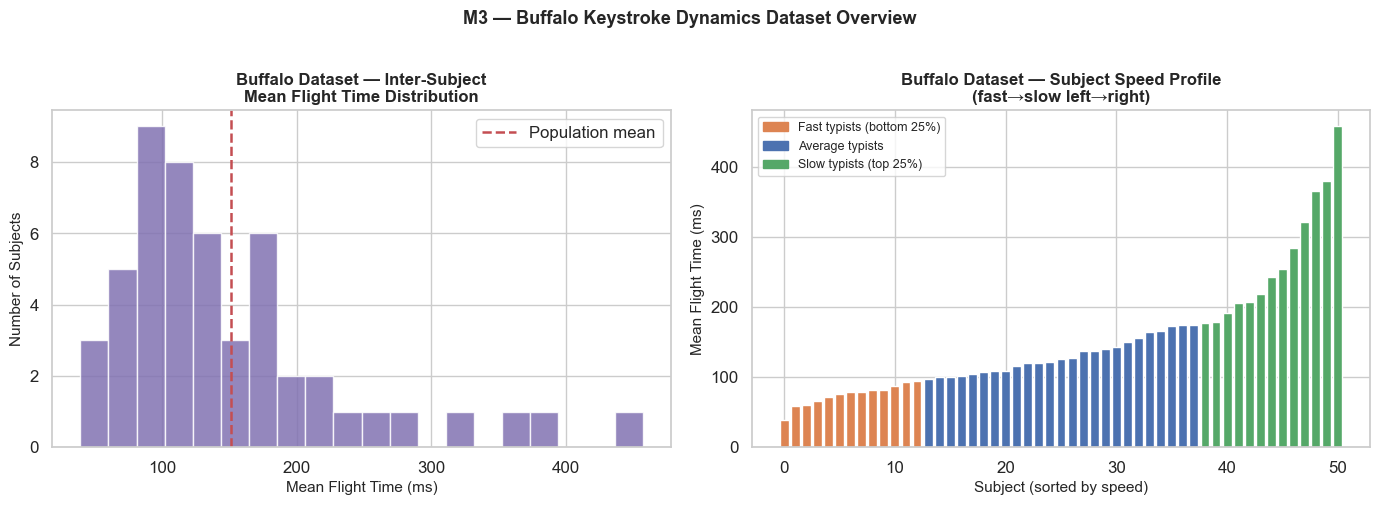

In [62]:
# ── 3.1  M3 — Buffalo: per-subject mean flight time distribution ──────────────
subj_stats = df_buffalo.groupby('subject')[UD_COLS].mean()
subj_stats['mean_flight'] = subj_stats.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of mean flight times across subjects
ax = axes[0]
ax.hist(subj_stats['mean_flight'] * 1000, bins=20,
        color=PAL['mss'], edgecolor='white', alpha=0.85)
ax.set_xlabel('Mean Flight Time (ms)', fontsize=11)
ax.set_ylabel('Number of Subjects', fontsize=11)
ax.set_title('Buffalo Dataset — Inter-Subject\nMean Flight Time Distribution', fontsize=12, fontweight='bold')
ax.axvline(subj_stats['mean_flight'].mean() * 1000, ls='--',
           color=PAL['alert'], lw=1.8, label='Population mean')
ax.legend()

# Sorted subject profile
ax2 = axes[1]
sorted_means = (subj_stats['mean_flight'] * 1000).sort_values()
colors_bar   = [PAL['manic'] if v < sorted_means.quantile(0.25)
                else PAL['depressed'] if v > sorted_means.quantile(0.75)
                else PAL['normal']
                for v in sorted_means]
ax2.bar(range(len(sorted_means)), sorted_means.values, color=colors_bar, edgecolor='white')
ax2.set_xlabel('Subject (sorted by speed)', fontsize=11)
ax2.set_ylabel('Mean Flight Time (ms)', fontsize=11)
ax2.set_title('Buffalo Dataset — Subject Speed Profile\n(fast→slow left→right)', fontsize=12, fontweight='bold')
fast = mpatches.Patch(color=PAL['manic'],     label='Fast typists (bottom 25%)')
mid  = mpatches.Patch(color=PAL['normal'],    label='Average typists')
slow = mpatches.Patch(color=PAL['depressed'], label='Slow typists (top 25%)')
ax2.legend(handles=[fast, mid, slow], fontsize=9)

plt.suptitle('M3 — Buffalo Keystroke Dynamics Dataset Overview',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

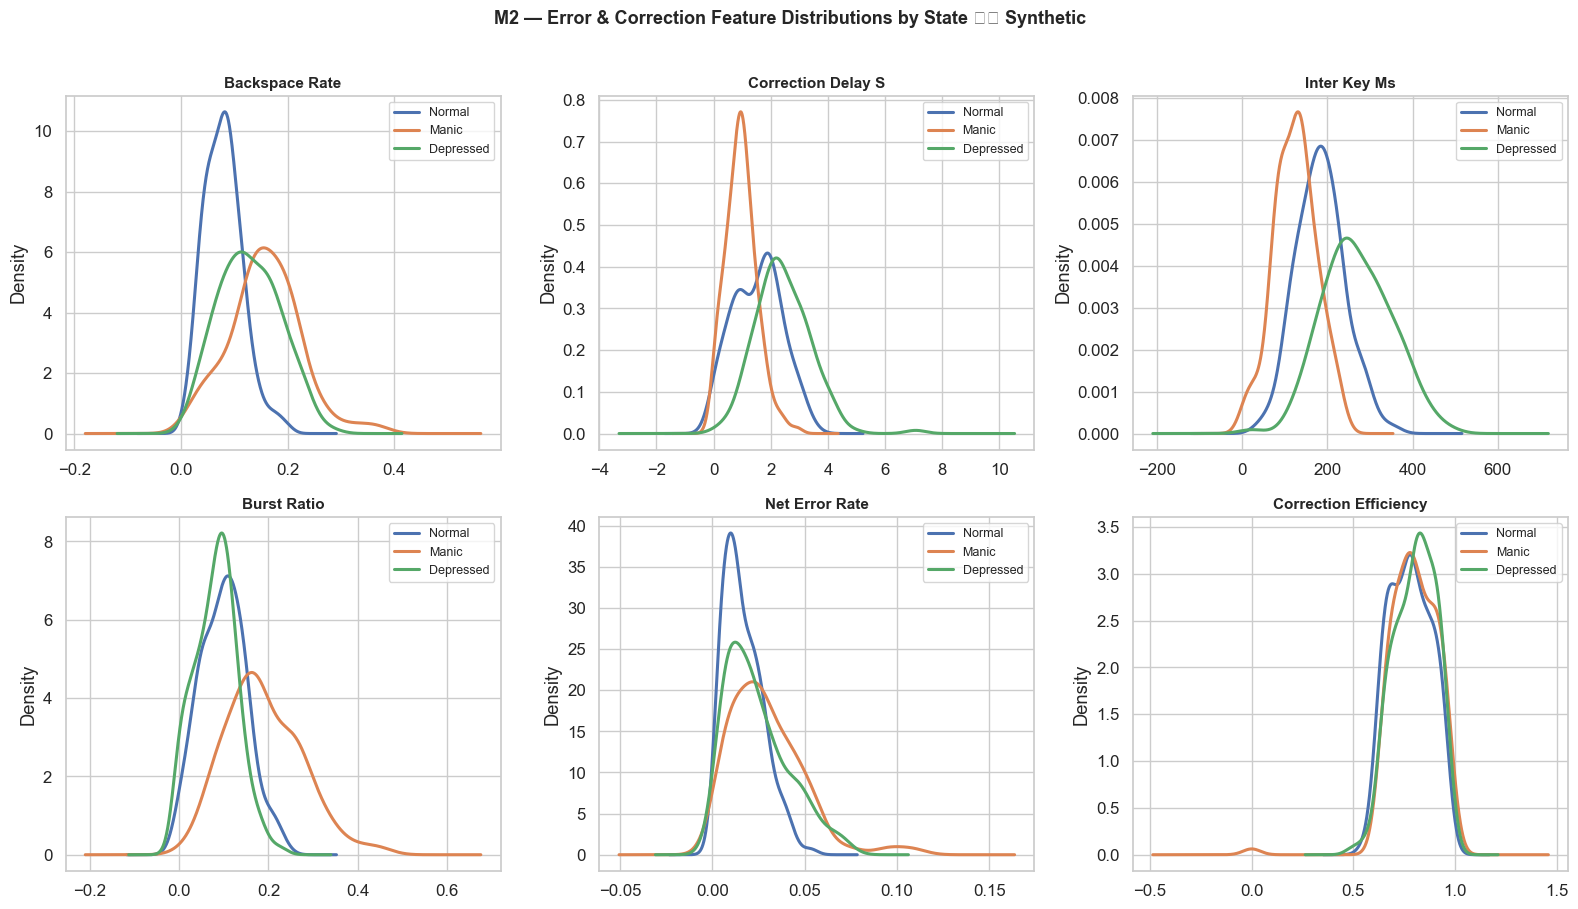

In [63]:
# ── 3.2  M2 — Error features by state ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

err_plot_cols = ['backspace_rate', 'correction_delay_s', 'inter_key_ms',
                 'burst_ratio', 'net_error_rate', 'correction_efficiency']

for ax, col in zip(axes, err_plot_cols):
    for state in ['normal', 'manic', 'depressed']:
        df_errors[df_errors['state'] == state][col].plot.kde(
            ax=ax, label=state.capitalize(), color=PAL[state], lw=2.2)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

plt.suptitle('M2 — Error & Correction Feature Distributions by State ⚠️ Synthetic',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

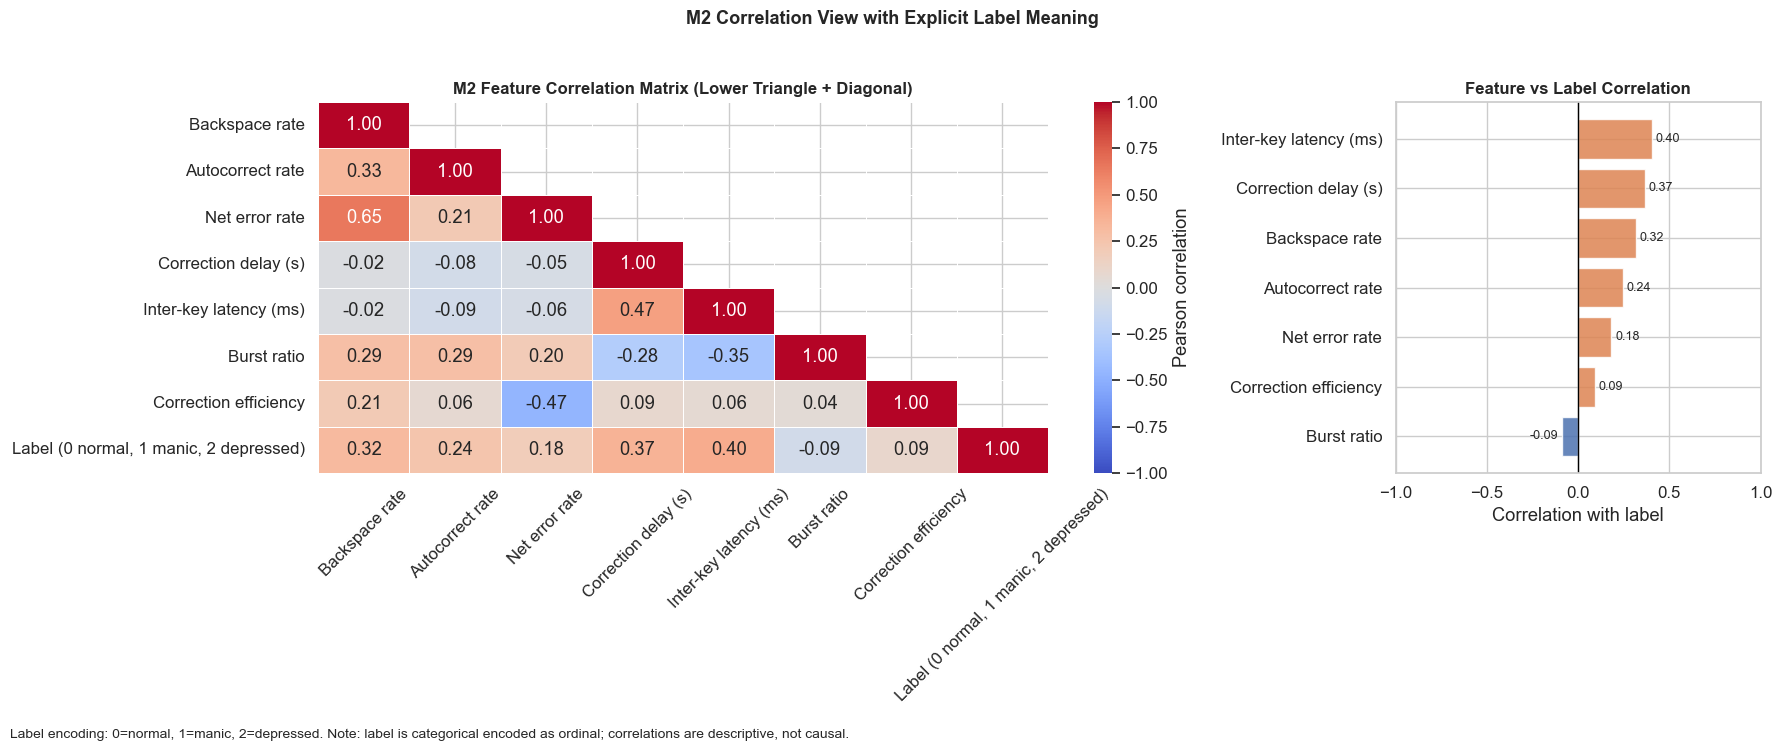

In [64]:
# -- 3.3 M2 Correlation analysis with explicit target-label interpretation -------
M2_CORR_COLS = [
    'backspace_rate', 'autocorrect_rate', 'net_error_rate',
    'correction_delay_s', 'inter_key_ms', 'burst_ratio',
    'correction_efficiency', 'label'
 ]

# Human-readable axis labels for better interpretation in presentations.
DISPLAY_NAMES = {
    'backspace_rate': 'Backspace rate',
    'autocorrect_rate': 'Autocorrect rate',
    'net_error_rate': 'Net error rate',
    'correction_delay_s': 'Correction delay (s)',
    'inter_key_ms': 'Inter-key latency (ms)',
    'burst_ratio': 'Burst ratio',
    'correction_efficiency': 'Correction efficiency',
    'label': 'Label (0 normal, 1 manic, 2 depressed)'
}

# Pearson matrix for pairwise linear association across engineered features.
corr = df_errors[M2_CORR_COLS].corr(method='pearson')
corr_disp = corr.rename(index=DISPLAY_NAMES, columns=DISPLAY_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2.5, 1]})

# Left panel: full matrix (diagonal visible) to avoid confusion around hidden cells.
mask = np.triu(np.ones_like(corr_disp, dtype=bool), k=1)
sns.heatmap(
    corr_disp,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'label': 'Pearson correlation'},
    ax=axes[0]
 )
axes[0].set_title('M2 Feature Correlation Matrix (Lower Triangle + Diagonal)',
                  fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Right panel: direct association with target label for quick reading.
label_corr = corr.drop(index='label')['label'].sort_values(key=np.abs, ascending=False)
label_corr_disp = label_corr.rename(index=DISPLAY_NAMES)
bar_colors = [PAL['manic'] if v >= 0 else PAL['normal'] for v in label_corr_disp.values]
axes[1].barh(label_corr_disp.index, label_corr_disp.values, color=bar_colors, alpha=0.85)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlim(-1, 1)
axes[1].set_xlabel('Correlation with label')
axes[1].set_title('Feature vs Label Correlation', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

for y_i, v in enumerate(label_corr_disp.values):
    axes[1].text(v + (0.02 if v >= 0 else -0.02), y_i, f'{v:.2f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

fig.suptitle('M2 Correlation View with Explicit Label Meaning',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(
    0.01, -0.02,
    'Label encoding: 0=normal, 1=manic, 2=depressed. Note: label is categorical encoded as ordinal; '
    'correlations are descriptive, not causal.',
    fontsize=10
)
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering <a id='4'></a>

This section transforms raw keystroke logs into clinically meaningful, model-ready variables.

### Why feature engineering is necessary

- Raw keystroke streams are noisy and high-dimensional.
- Clinical patterns (psychomotor slowing, agitation, impulsive correction behavior) are not directly observable from one raw event.
- Engineered features compress each subject/session into interpretable biomarkers suitable for robust modeling.

### Labeling policy used in this notebook

- **M2 labels (`label`)** come from the synthetic BiAffect-compatible generator and map directly to classes:
  - `0 = normal`
  - `1 = manic`
  - `2 = depressed`
- **M3 labels (`speed_label`)** are **proxy labels** derived from population speed quantiles because Buffalo data has no clinical diagnosis labels.
- Therefore, M3 labels should be interpreted as **motor-speed phenotypes**, not medical diagnoses.

### 4.1 M3 — Timing Features from Buffalo Data <a id='4-1'></a>

In [65]:
def extract_timing_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert raw Buffalo keystroke timing to one feature vector per subject.

    Clinical/behavioral rationale
    ---------------------------
    - Flight-time statistics capture psychomotor speed and instability.
    - Hold-time statistics capture key-press control and motor steadiness.
    - Digraph-time statistics capture cross-key coordination dynamics.
    - Rhythm features (CV, burst_count, slow_count, hold_flight_ratio) capture
      agitation bursts vs psychomotor retardation patterns.

    Processing choices
    ------------------
    - Convert seconds to milliseconds for interpretability.
    - Remove non-positive timings as measurement artifacts.
    - Fill NaN values with 0 after aggregation to keep matrix complete.

    Returns
    -------
    pd.DataFrame
        One row per subject with engineered timing features.
    """
    records = []
    for subj, grp in df.groupby('subject'):
        # Convert seconds to milliseconds (human-interpretable scale).
        ht_ms  = grp[H_COLS].values.flatten()  * 1000
        ud_ms  = grp[UD_COLS].values.flatten() * 1000
        dd_ms  = grp[DD_COLS].values.flatten() * 1000

        # Remove non-positive values that are likely logging artifacts.
        ud_ms = ud_ms[ud_ms > 0]
        ht_ms = ht_ms[ht_ms > 0]
        dd_ms = dd_ms[dd_ms > 0]

        records.append({
            'subject':          subj,
            # Flight-time descriptors (speed + variability + tail behavior).
            'mean_flight':      np.mean(ud_ms),
            'std_flight':       np.std(ud_ms),
            'median_flight':    np.median(ud_ms),
            'p10_flight':       np.percentile(ud_ms, 10),
            'p90_flight':       np.percentile(ud_ms, 90),
            'iqr_flight':       np.percentile(ud_ms, 75) - np.percentile(ud_ms, 25),
            'skew_flight':      pd.Series(ud_ms).skew(),
            'kurt_flight':      pd.Series(ud_ms).kurt(),
            # Hold-time descriptors (motor control during press).
            'mean_hold':        np.mean(ht_ms),
            'std_hold':         np.std(ht_ms),
            'p10_hold':         np.percentile(ht_ms, 10),
            'p90_hold':         np.percentile(ht_ms, 90),
            # Digraph descriptors (inter-key motor coordination).
            'mean_digraph':     np.mean(dd_ms),
            'std_digraph':      np.std(dd_ms),
            # Rhythm/instability descriptors.
            'rhythm_cv':        np.std(ud_ms) / (np.mean(ud_ms) + 1e-6),
            'burst_count':      int((ud_ms < 40).sum()),
            'slow_count':       int((ud_ms > 300).sum()),
            'hold_flight_ratio':np.mean(ht_ms) / (np.mean(ud_ms) + 1e-6),
        })

    return pd.DataFrame(records).fillna(0)


df_timing = extract_timing_features(df_buffalo)

# NOTE: mean/median/p10/p90 of flight are EXCLUDED from the classifier feature
# set to avoid target leakage. The proxy label `speed_label` (built later) is a
# deterministic threshold on `mean_flight`, so including it (or its near-duplicate
# central-tendency stats) lets tree models recover the labeling rule perfectly
# (XGBoost previously reached F1=1.000 this way). We keep distribution-shape
# flight features (std, iqr, skew, kurt), which describe rhythm without revealing
# the central tendency that defines the labels. `mean_flight` itself stays in
# `df_timing` because the labeling step and MSS regression target rely on it.
M3_FEAT_COLS = [
    'std_flight','iqr_flight','skew_flight','kurt_flight',
    'mean_hold','std_hold','p10_hold','p90_hold',
    'mean_digraph','std_digraph',
    'rhythm_cv','burst_count','slow_count','hold_flight_ratio',
]

print(f'Timing feature matrix : {df_timing.shape[0]} subjects x {len(M3_FEAT_COLS)} features')
print('Feature groups: flight(4), hold(4), digraph(2), rhythm(4)')
df_timing.describe().round(2)

Timing feature matrix : 51 subjects x 14 features
Feature groups: flight(4), hold(4), digraph(2), rhythm(4)


,mean_flight,std_flight,median_flight,p10_flight,p90_flight,iqr_flight,skew_flight,kurt_flight,mean_hold,std_hold,p10_hold,p90_hold,mean_digraph,std_digraph,rhythm_cv,burst_count,slow_count,hold_flight_ratio
count,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00
mean,170.90,180.88,115.97,32.22,365.30,160.42,3.89,49.18,90.28,22.70,64.48,119.81,241.12,176.90,1.08,620.24,533.27,0.62
std,80.77,90.79,71.00,29.00,151.72,64.09,3.27,133.66,19.58,7.57,13.24,26.97,83.67,90.96,0.19,324.69,469.34,0.26
min,75.04,81.42,46.70,6.86,131.98,87.00,1.33,2.61,46.11,8.73,35.60,58.10,134.43,76.99,0.73,2.00,56.00,0.10
25%,119.19,123.71,70.62,14.29,260.38,109.40,2.64,12.13,81.48,18.14,56.45,105.80,184.42,120.47,0.95,348.50,184.00,0.46
50%,139.68,161.20,88.60,22.20,336.10,147.15,3.18,16.51,89.34,21.70,63.60,118.40,212.95,155.88,1.08,679.00,414.00,0.62
75%,190.72,202.97,136.25,37.14,438.65,174.60,3.62,24.80,98.51,25.63,71.15,130.60,263.47,199.55,1.19,877.50,698.00,0.76
max,457.28,661.41,422.20,144.48,794.85,319.78,19.45,750.32,143.53,45.03,103.00,191.21,503.95,662.49,1.81,1205.00,2414.00,1.28


In [66]:
# Assign speed-based proxy labels from Buffalo timing features.
# Buffalo has no diagnostic mood labels; we therefore use quantile-based motor classes.
# This yields balanced, reproducible classes for model training/evaluation.
# Interpretation: these are MOTOR PHENOTYPES, not clinical diagnoses.

q33 = df_timing['mean_flight'].quantile(0.33)
q67 = df_timing['mean_flight'].quantile(0.67)

# Label rule justification:
# - lower third mean_flight -> fast motor profile (manic-like proxy)
# - middle third          -> normative motor speed
# - upper third           -> slow motor profile (depressed-like proxy)
df_timing['speed_label'] = df_timing['mean_flight'].apply(
    lambda x: 'manic' if x < q33 else ('depressed' if x > q67 else 'normal')
)
df_timing['speed_label_int'] = df_timing['speed_label'].map(LABEL_MAP)
 
print('M3 proxy label thresholds (ms):')
print(f'  q33 (fast cutoff) = {q33:.2f}')
print(f'  q67 (slow cutoff) = {q67:.2f}')
print()
print('Speed proxy label distribution:')
print(df_timing['speed_label'].value_counts())
print()
print('Label mapping used by the classifier:')
print("  normal -> 0, manic -> 1, depressed -> 2")

M3 proxy label thresholds (ms):
  q33 (fast cutoff) = 126.51
  q67 (slow cutoff) = 177.51

Speed proxy label distribution:
speed_label
normal       17
manic        17
depressed    17
Name: count, dtype: int64

Label mapping used by the classifier:
  normal -> 0, manic -> 1, depressed -> 2


### 4.2 M2 — Precision & Error Features <a id='4-2'></a>

### Why these M2 features were engineered

- `typo_spike_flag`: captures acute error bursts above baseline (possible impulsive episodes).
- `speed_category`: discretizes inter-key latency into interpretable motor states (fast/normal/slow).
- `error_load`: combines backspace and autocorrect rates into a global correction burden.
- `correction_ratio`: estimates how effectively typed errors are repaired.

### Label justification for M2

- Labels are generated from state-conditioned synthetic profiles designed to reflect plausible behavioral patterns.
- The `label` column is encoded as: `normal=0`, `manic=1`, `depressed=2`.
- This encoding is used only for model training convenience; clinically, the target remains categorical.
- If you replace synthetic data with external data later, keep the same label mapping for compatibility.

In [67]:
def build_error_features(df: pd.DataFrame, ref_stats: dict = None) -> pd.DataFrame:
    """
    Engineer clinically interpretable M2 precision/error features.

    Original features (4)
    ---------------------
    typo_spike_flag    : 1 if backspace_rate > mean + 1.5*std (session unusually error-heavy)
    error_load         : backspace_rate + autocorrect_rate  (total correction burden)
    correction_ratio   : n_corrections / n_backspace  (how often user follows through)
    speed_category     : fast / normal / slow bin from inter_key_ms

    NEW features added for accuracy improvement (9)
    ------------------------------------------------
    speed_error_ix     : inter_key_ms × backspace_rate  (fast+error = manic signal)
    burst_error_ix     : burst_ratio   × net_error_rate (bursty+errors = impulsivity)
    errors_per_100ks   : backspace presses per 100 keystrokes (normalised error rate)
    log_correction_delay: log1p of correction_delay_s  (compresses right tail)
    log_inter_key_ms   : log1p of inter_key_ms         (normalises skewed speed dist.)
    speed_deviation    : |inter_key_ms - 180|           (distance from median typist)
    extreme_speed_flag : 1 if typing is very fast (<80 ms) OR very slow (>350 ms)
    high_burst_flag    : 1 if burst_ratio > 0.15
    error_consistency  : 1 / backspace_rate  (low = erratic / impulsive typing)

    Leakage note
    ------------
    Threshold stats (mean_backspace_rate, std_backspace_rate) are computed on the
    training set only and passed in via ref_stats for the test set.
    """
    df = df.copy()

    # ── threshold stats (train-set derived) ───────────────────────────────────
    if ref_stats is None:
        global_mean_br = df['backspace_rate'].mean()
        global_std_br  = df['backspace_rate'].std()
    else:
        global_mean_br = ref_stats['mean_backspace_rate']
        global_std_br  = ref_stats['std_backspace_rate']

    # ── original derived features ─────────────────────────────────────────────
    df['typo_spike_flag'] = (
        df['backspace_rate'] > global_mean_br + 1.5 * global_std_br
    ).astype(int)

    df['speed_category']  = pd.cut(
        df['inter_key_ms'], bins=[0, 100, 200, 800],
        labels=['fast', 'normal', 'slow']
    )
    df['error_load']       = df['backspace_rate'] + df['autocorrect_rate']
    df['correction_ratio'] = df['n_corrections']  / df['n_backspace'].clip(1)

    # ── NEW: interaction features ─────────────────────────────────────────────
    # Fast typing + many errors → strong manic signal
    df['speed_error_ix']   = df['inter_key_ms'] * df['backspace_rate']
    # Bursty typing + uncorrected errors → impulsivity signal
    df['burst_error_ix']   = df['burst_ratio']  * df['net_error_rate']

    # ── NEW: normalised / transformed features ────────────────────────────────
    df['errors_per_100ks']     = (df['n_backspace'] / df['n_keystrokes'].clip(1)) * 100
    df['log_correction_delay'] = np.log1p(df['correction_delay_s'])
    df['log_inter_key_ms']     = np.log1p(df['inter_key_ms'])

    # ── NEW: deviation / flag features ────────────────────────────────────────
    MEDIAN_IK_MS = 180   # rough population median inter-key latency
    df['speed_deviation']    = np.abs(df['inter_key_ms'] - MEDIAN_IK_MS)
    df['extreme_speed_flag'] = (
        (df['inter_key_ms'] < 80) | (df['inter_key_ms'] > 350)
    ).astype(int)
    df['high_burst_flag']    = (df['burst_ratio'] > 0.15).astype(int)
    df['error_consistency']  = 1.0 / df['backspace_rate'].clip(0.01)

    return df


df_errors_raw = df_errors.copy()
df_errors     = build_error_features(df_errors_raw)

# ── Feature column list (19 total) ────────────────────────────────────────────
M2_FEAT_COLS = [
    # --- original raw features ---
    'backspace_rate', 'autocorrect_rate', 'net_error_rate',
    'correction_delay_s', 'inter_key_ms', 'burst_ratio', 'correction_efficiency',
    # --- original derived features ---
    'typo_spike_flag', 'error_load', 'correction_ratio',
    # --- NEW: interaction features ---
    'speed_error_ix', 'burst_error_ix',
    # --- NEW: log-transformed features ---
    'log_correction_delay', 'log_inter_key_ms',
    # --- NEW: deviation / flag features ---
    'errors_per_100ks', 'speed_deviation',
    'extreme_speed_flag', 'high_burst_flag', 'error_consistency',
]

print(f'Error feature matrix : {df_errors.shape[0]} sessions  ×  {len(M2_FEAT_COLS)} features')
print('Label mapping: normal=0  |  manic=1  |  depressed=2')
print()
print('Per-class feature means (rounded):')
df_errors.groupby('state')[M2_FEAT_COLS[:10]].mean().round(3)


Error feature matrix : 450 sessions  ×  19 features
Label mapping: normal=0  |  manic=1  |  depressed=2

Per-class feature means (rounded):


,backspace_rate,autocorrect_rate,net_error_rate,correction_delay_s,inter_key_ms,burst_ratio,correction_efficiency,typo_spike_flag,error_load,correction_ratio
state,,,,,,,,,,
depressed,0.129,0.082,0.024,2.426,270.356,0.082,0.802,0.087,0.210,0.802
manic,0.157,0.101,0.029,0.968,124.790,0.189,0.798,0.147,0.258,0.798
normal,0.079,0.057,0.017,1.530,184.191,0.099,0.778,0.000,0.136,0.778


### 4.3 Feature Dictionary (Justification + Clinical Direction)

This table summarizes the full feature set used downstream, including how each feature is computed and why it is clinically relevant.

| Feature | Module | Type | Definition / Formula | Clinical interpretation | Expected trend (relative) |
|---|---|---|---|---|---|
| `mean_flight` | M3 | Extracted | Mean of UD latencies (ms) | Core psychomotor speed marker | manic ↓, depressed ↑ |
| `std_flight` | M3 | Extracted | Standard deviation of UD latencies | Motor rhythm instability | manic ↑ (variable bursts), depressed ↑ (irregular slowing) |
| `median_flight` | M3 | Extracted | Median UD latency | Robust central speed estimate | manic ↓, depressed ↑ |
| `p10_flight`, `p90_flight` | M3 | Extracted | 10th and 90th percentiles of UD latency | Fast/slow tail behavior | manic: lower p10; depressed: higher p90 |
| `iqr_flight` | M3 | Extracted | Q3 - Q1 of UD latency | Within-subject variability | both episodes may increase spread |
| `skew_flight`, `kurt_flight` | M3 | Extracted | Distribution asymmetry and tail-heaviness | Detects non-Gaussian burst/slow patterns | episode states deviate from normal |
| `mean_hold`, `std_hold`, `p10_hold`, `p90_hold` | M3 | Extracted | Statistics of key hold durations (ms) | Press control and motor steadiness | manic often shorter/faster holds; depressed longer holds |
| `mean_digraph`, `std_digraph` | M3 | Extracted | Statistics of DD timings (ms) | Inter-key coordination and transition timing | manic ↓ mean; depressed ↑ mean |
| `rhythm_cv` | M3 | Extracted | std_flight / (mean_flight + 1e-6) | Normalized rhythm irregularity | manic/depressed often ↑ vs normal |
| `burst_count` | M3 | Extracted | Count of very fast flights (`UD < 40ms`) | Agitation / impulsive bursts | manic ↑ |
| `slow_count` | M3 | Extracted | Count of very slow flights (`UD > 300ms`) | Psychomotor retardation episodes | depressed ↑ |
| `hold_flight_ratio` | M3 | Extracted | mean_hold / (mean_flight + 1e-6) | Relative dwell vs transition dynamics | profile-specific dysregulation indicator |
| `backspace_rate` | M2 | Base | backspaces / keystrokes | Error-proneness and correction need | manic ↑, depressed ↑ (different mechanisms) |
| `autocorrect_rate` | M2 | Base | autocorrects / keystrokes | External correction reliance | manic ↑ |
| `net_error_rate` | M2 | Base | (backspaces - corrections) / keystrokes | Residual error burden | manic ↑, depressed ↑ |
| `correction_delay_s` | M2 | Base | Delay between error and correction | Cognitive/motor correction latency | depressed ↑, manic ↓ |
| `inter_key_ms` | M2 | Base | Mean inter-key interval (ms) | Session-level typing speed | manic ↓, depressed ↑ |
| `burst_ratio` | M2 | Base | Proportion of rapid bursts in session | Impulsive typing chunks | manic ↑ |
| `correction_efficiency` | M2 | Base | corrections / max(backspaces,1) | Repair quality under errors | normal usually ↑ |
| `typo_spike_flag` | M2 | Engineered | 1 if `backspace_rate > mean + 1.5*std` | Acute impulsive error episode marker | manic ↑ |
| `speed_category` | M2 | Engineered | Bin of `inter_key_ms`: fast/normal/slow | Interpretable motor state abstraction | manic -> fast, depressed -> slow |
| `error_load` | M2 | Engineered | `backspace_rate + autocorrect_rate` | Global correction burden | manic/depressed ↑ vs normal |
| `correction_ratio` | M2 | Engineered | `n_corrections / max(n_backspace,1)` | Error repair success | normal typically ↑ |

### Label policy used by models

- M2 target label (categorical encoded): `normal=0`, `manic=1`, `depressed=2`.
- M3 target label is proxy-only: `speed_label` built from flight-time quantiles (`q33`, `q67`).
- Interpretation note: M3 labels are motor phenotypes, not clinical diagnoses.

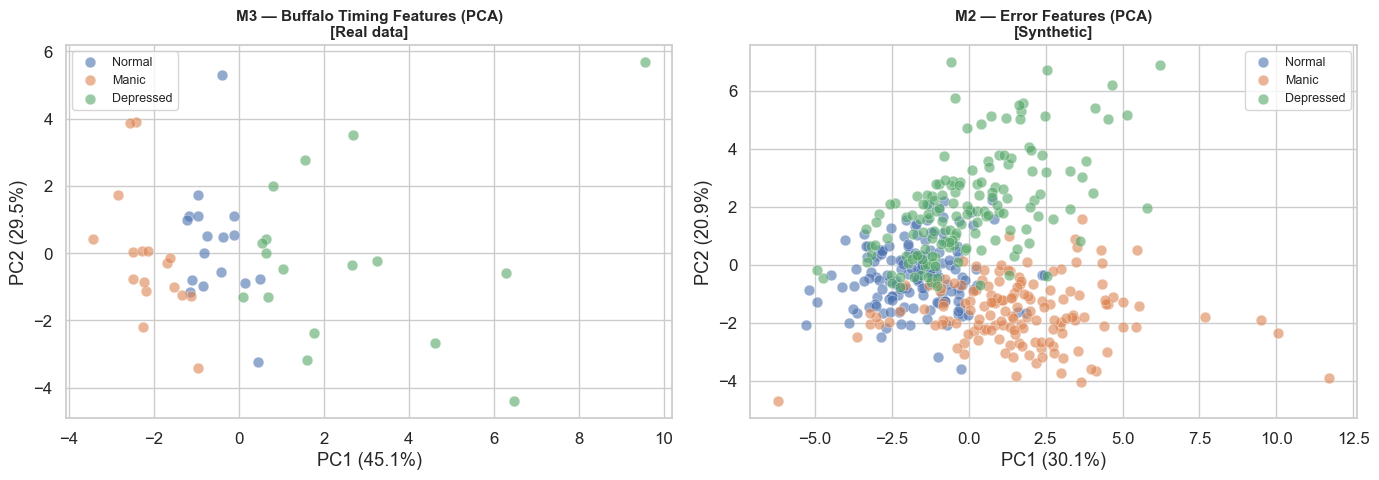

In [68]:
# ── PCA — both feature sets side by side ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat_df, feat_cols, label_col, title, dataset_tag in [
    (axes[0], df_timing, M3_FEAT_COLS, 'speed_label',
     'M3 — Buffalo Timing Features (PCA)', 'Real data'),
    (axes[1], df_errors, M2_FEAT_COLS, 'state',
     'M2 — Error Features (PCA)', 'Synthetic'),
]:
    scaler = StandardScaler()
    Xs = scaler.fit_transform(feat_df[feat_cols])
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    Xp  = pca.fit_transform(Xs)
    for state, color in PAL.items():
        if state in ('normal','manic','depressed'):
            mask = feat_df[label_col] == state
            ax.scatter(Xp[mask, 0], Xp[mask, 1], c=color,
                       label=state.capitalize(), alpha=0.6, s=60,
                       edgecolors='white', lw=0.4)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'{title}\n[{dataset_tag}]', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. M3 — KNN Classifier & Motor Speed Score (Ridge Regression) <a id='5'></a>

### 5.1 M3 — KNN Classifier

In [69]:
# ── Train / test split with TRAIN-ONLY threshold derivation ──────────────────
# Why this matters: previously q33/q67 were computed on the FULL df_timing
# before splitting, so test subjects' mean_flight values informed the label
# boundary used at evaluation time. With n=51 the magnitude is small, but the
# correct procedure is to compute population statistics on training data only
# and reapply them to the held-out test set.
#
# We split on subjects, not on labels: the global proxy labels in df_timing
# are kept for visualization, but the labels used to TRAIN and EVALUATE the
# M3 classifier are re-derived using train-only thresholds.

X3_full = df_timing[M3_FEAT_COLS].values
mean_flight_all = df_timing['mean_flight'].values

# Random subject-level split. Stratify on the global labels so each side stays
# roughly class-balanced; the exact label values are recomputed below.
y3_global = df_timing['speed_label_int'].values.astype(int)
idx = np.arange(len(df_timing))
idx_tr, idx_te = train_test_split(
    idx, test_size=0.25, stratify=y3_global, random_state=RANDOM_STATE
)

X3_tr, X3_te = X3_full[idx_tr], X3_full[idx_te]

# Train-only thresholds → applied to BOTH train and test labels.
q33_tr = np.quantile(mean_flight_all[idx_tr], 0.33)
q67_tr = np.quantile(mean_flight_all[idx_tr], 0.67)

def _label_from_flight(mf: np.ndarray, q33: float, q67: float) -> np.ndarray:
    out = np.full(mf.shape, LABEL_MAP['normal'], dtype=int)
    out[mf < q33] = LABEL_MAP['manic']
    out[mf > q67] = LABEL_MAP['depressed']
    return out

y3_tr = _label_from_flight(mean_flight_all[idx_tr], q33_tr, q67_tr)
y3_te = _label_from_flight(mean_flight_all[idx_te], q33_tr, q67_tr)

print('M3 train-only thresholds (ms):')
print(f'  q33 (train) = {q33_tr:.2f}    q67 (train) = {q67_tr:.2f}')
print(f'  train labels: {np.bincount(y3_tr, minlength=3)} (Normal/Manic/Depressed)')
print(f'  test  labels: {np.bincount(y3_te, minlength=3)} (Normal/Manic/Depressed)')

# Aliases for backward compatibility with the rest of the notebook.
X3 = X3_full
y3 = y3_global

# ── KNN with grid search ──────────────────────────────────────────────────────
knn_pipe = Pipeline([('sc', StandardScaler()),
                     ('knn', KNeighborsClassifier(metric='euclidean'))])
grid = GridSearchCV(knn_pipe, {'knn__n_neighbors': [3, 5, 7, 9, 11]},
                    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                    scoring='f1_macro', n_jobs=-1)
grid.fit(X3_tr, y3_tr)
best_knn = grid.best_estimator_
knn_cv_mean = grid.best_score_
knn_cv_std  = grid.cv_results_['std_test_score'][grid.best_index_]
print(f'KNN best k       : {grid.best_params_["knn__n_neighbors"]}')
print(f'KNN CV F1 macro  : {knn_cv_mean:.3f} ± {knn_cv_std:.3f}')


M3 train-only thresholds (ms):
  q33 (train) = 125.96    q67 (train) = 173.66
  train labels: [12 13 13] (Normal/Manic/Depressed)
  test  labels: [5 3 5] (Normal/Manic/Depressed)
KNN best k       : 3
KNN CV F1 macro  : 0.769 ± 0.109


### 5.2 M3 — XGBoost Classifier

In [70]:
# ── XGBoost with randomized search ────────────────────────────────────────────
print('\n── Tuning XGBoost (M3) … ──')
xgb_param_grid = {
    'n_estimators':     [200, 400],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'min_child_weight': [1, 3],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softprob', num_class=3,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ),
    param_distributions=xgb_param_grid,
    n_iter=25,
    scoring='f1_macro',
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
xgb_search.fit(X3_tr, y3_tr)
best_xgb = xgb_search.best_estimator_
xgb_cv_mean = xgb_search.best_score_
xgb_cv_std  = xgb_search.cv_results_['std_test_score'][xgb_search.best_index_]
print(f'XGB best params  : {xgb_search.best_params_}')
print(f'XGB CV F1 macro  : {xgb_cv_mean:.3f} ± {xgb_cv_std:.3f}')

# Select best M3 classifier based on CV score (train-only).
best_m3_cls = best_knn if knn_cv_mean >= xgb_cv_mean else best_xgb
best_m3_name = 'KNN' if best_m3_cls is best_knn else 'XGBoost'
print(f'\nSelected M3 classifier (by CV): {best_m3_name}')



── Tuning XGBoost (M3) … ──
XGB best params  : {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
XGB CV F1 macro  : 0.882 ± 0.112

Selected M3 classifier (by CV): XGBoost


### 5.3 M3 — Motor Speed Score (Ridge Regression)

In [71]:
# ── Motor Speed Score via Ridge Regression ────────────────────────────────────
# Target: normalized inverse of mean_flight (higher MSS = faster typing)
mss_raw  = 1.0 / (df_timing['mean_flight'] + 1e-6)
mss_norm = MinMaxScaler().fit_transform(mss_raw.values.reshape(-1,1)).flatten()
df_timing['MSS'] = mss_norm

y3_reg = mss_norm
# Use a consistent split for regression features/targets.
idx = np.arange(len(X3))
idx_tr, idx_te = train_test_split(
    idx, test_size=0.25, stratify=y3, random_state=RANDOM_STATE
)
X3_reg_tr, X3_reg_te = X3[idx_tr], X3[idx_te]
y3_reg_tr, y3_reg_te = y3_reg[idx_tr], y3_reg[idx_te]

ridge_pipe = Pipeline([('sc', StandardScaler()),
                       ('ridge', RidgeCV(alphas=[0.01,0.1,1,10,100], cv=5))])
ridge_pipe.fit(X3_reg_tr, y3_reg_tr)
mss_pred_te = np.clip(ridge_pipe.predict(X3_reg_te), 0, 1)

print(f'Ridge R²       : {r2_score(y3_reg_te, mss_pred_te):.3f}')
print(f'Ridge MAE      : {mean_absolute_error(y3_reg_te, mss_pred_te):.4f}')

Ridge R²       : 0.955
Ridge MAE      : 0.0336


### 5.4 M3 — Evaluation Plots (KNN vs XGBoost + MSS)

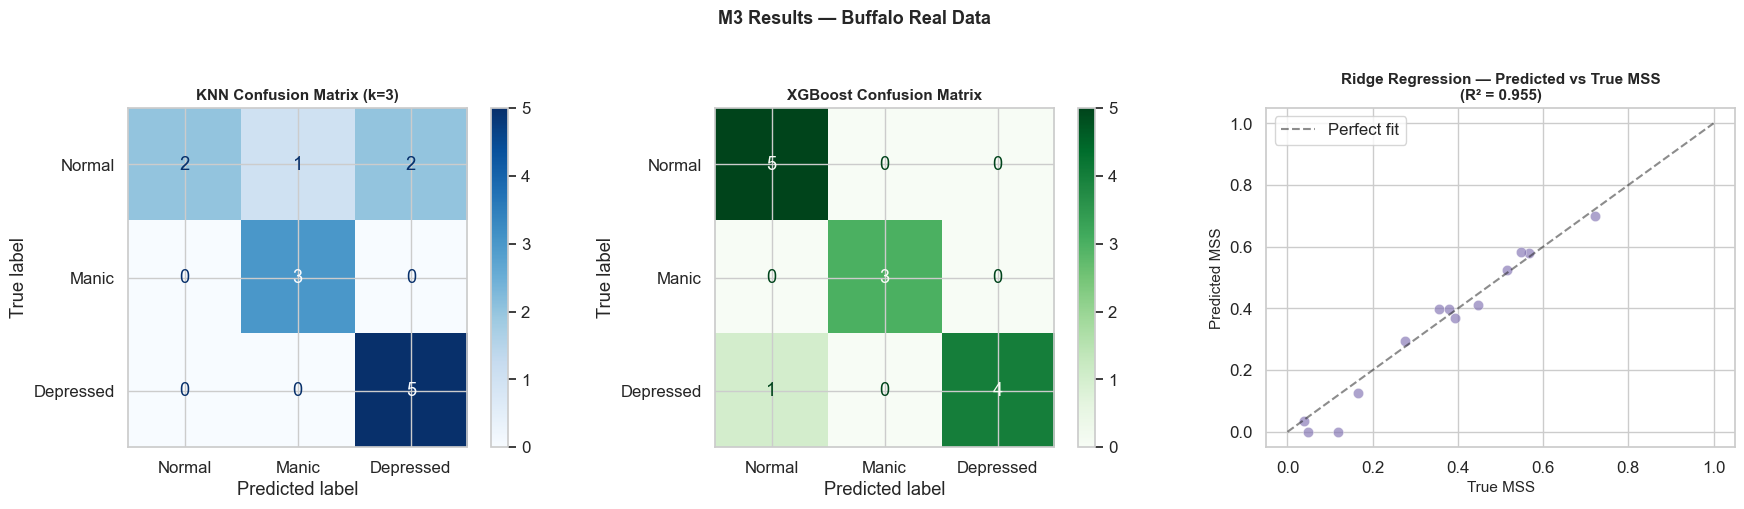

In [72]:
# ── M3 evaluation plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix — KNN
ConfusionMatrixDisplay.from_predictions(
    y3_te, best_knn.predict(X3_te),
    display_labels=['Normal','Manic','Depressed'],
    cmap='Blues', ax=axes[0]
 )
axes[0].set_title(f'KNN Confusion Matrix (k={grid.best_params_["knn__n_neighbors"]})',
                  fontsize=11, fontweight='bold')

# Confusion matrix — XGBoost
ConfusionMatrixDisplay.from_predictions(
    y3_te, best_xgb.predict(X3_te),
    display_labels=['Normal','Manic','Depressed'],
    cmap='Greens', ax=axes[1]
 )
axes[1].set_title('XGBoost Confusion Matrix', fontsize=11, fontweight='bold')

# Predicted vs actual MSS
axes[2].scatter(y3_reg_te, mss_pred_te, alpha=0.65, s=55,
                color=PAL['mss'], edgecolors='white', lw=0.4)
axes[2].plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5, label='Perfect fit')
axes[2].set_xlabel('True MSS', fontsize=11)
axes[2].set_ylabel('Predicted MSS', fontsize=11)
axes[2].set_title(f'Ridge Regression — Predicted vs True MSS\n(R² = {r2_score(y3_reg_te, mss_pred_te):.3f})',
                  fontsize=11, fontweight='bold')
axes[2].legend()

plt.suptitle('M3 Results — Buffalo Real Data', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. M2 — Random Forest & Impulsivity / Confusion Index <a id='6'></a>

In [73]:
# ── Train / test split (grouped by user — NO LEAKAGE) ─────────────────────────
# Users are split at the GROUP level: all sessions from a given user go to
# either train OR test, never both. This prevents the model from memorising
# user-specific typing quirks during training and then "recognising" the same
# user at test time.

base_cols = [
    'session_id', 'user_id', 'state', 'label',
    'n_keystrokes', 'backspace_rate', 'autocorrect_rate',
    'n_backspace', 'n_autocorrect', 'n_corrections',
    'net_error_rate', 'correction_delay_s', 'inter_key_ms',
    'burst_ratio', 'correction_efficiency'
]

df_m2_base = df_errors_raw[base_cols].copy()
groups     = df_m2_base['user_id'].values
y_all      = df_m2_base['label'].values.astype(int)

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(df_m2_base, y_all, groups=groups))

df2_tr_base = df_m2_base.iloc[tr_idx].copy()
df2_te_base = df_m2_base.iloc[te_idx].copy()

print(f'Train: {len(df2_tr_base)} sessions  |  '
      f'{df2_tr_base["user_id"].nunique()} unique users')
print(f'Test : {len(df2_te_base)} sessions  |  '
      f'{df2_te_base["user_id"].nunique()} unique users')
print(f'User overlap (should be 0): '
      f'{len(set(df2_tr_base["user_id"]) & set(df2_te_base["user_id"]))}')

# Compute threshold stats from TRAINING data only, then apply to both sets
ref_stats = {
    'mean_backspace_rate': df2_tr_base['backspace_rate'].mean(),
    'std_backspace_rate':  df2_tr_base['backspace_rate'].std(),
}
df2_tr = build_error_features(df2_tr_base, ref_stats=ref_stats)
df2_te = build_error_features(df2_te_base, ref_stats=ref_stats)

X2_tr = df2_tr[M2_FEAT_COLS].values
X2_te = df2_te[M2_FEAT_COLS].values
y2_tr = df2_tr['label'].values.astype(int)
y2_te = df2_te['label'].values.astype(int)

print(f'\nLabel distribution — Train: {dict(zip(*np.unique(y2_tr, return_counts=True)))}')
print(f'Label distribution — Test : {dict(zip(*np.unique(y2_te, return_counts=True)))}')
print('(0=Normal, 1=Manic, 2=Depressed)')

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1 — Tuned Random Forest
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Tuning Random Forest … ──')
rf_param_grid = {
    'n_estimators':     [200, 400],
    'max_depth':        [None, 15, 25],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2'],
    'class_weight':     ['balanced', 'balanced_subsample'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring='f1_macro',
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
rf_search.fit(X2_tr, y2_tr)
rf = rf_search.best_estimator_
print(f'  Best RF params : {rf_search.best_params_}')
print(f'  RF CV F1-macro : {rf_search.best_score_:.3f}')

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2 — XGBoost
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Tuning XGBoost … ──')
xgb_param_grid = {
    'n_estimators':     [200, 400],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'min_child_weight': [1, 3],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softprob', num_class=3,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='f1_macro',
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
xgb_search.fit(X2_tr, y2_tr)
xgb_clf = xgb_search.best_estimator_
print(f'  Best XGB params : {xgb_search.best_params_}')
print(f'  XGB CV F1-macro : {xgb_search.best_score_:.3f}')

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3 — Gradient Boosting
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Training Gradient Boosting … ──')
gb_clf = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.08, max_depth=5,
    min_samples_leaf=3, subsample=0.85, random_state=RANDOM_STATE
)
gb_clf.fit(X2_tr, y2_tr)
gb_cv = cross_val_score(gb_clf, X2_tr, y2_tr,
                        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                        scoring='f1_macro')
print(f'  GB CV F1-macro  : {gb_cv.mean():.3f} ± {gb_cv.std():.3f}')

# ─────────────────────────────────────────────────────────────────────────────
# ENSEMBLE — Soft-Voting Classifier (combines all 3)
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Building Soft-Voting Ensemble … ──')
ensemble = VotingClassifier(
    estimators=[
        ('rf',  rf),
        ('xgb', xgb_clf),
        ('gb',  gb_clf),
    ],
    voting='soft',   # averages class probabilities — more robust than hard vote
    n_jobs=-1
)
ensemble.fit(X2_tr, y2_tr)

# Cross-validate the ensemble on training data only
ens_cv = cross_val_score(
    ensemble, X2_tr, y2_tr,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro'
)
print(f'  Ensemble CV F1-macro : {ens_cv.mean():.3f} ± {ens_cv.std():.3f}')

# ─────────────────────────────────────────────────────────────────────────────
# COMPARE all models on the HELD-OUT test set
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('  M2 MODEL COMPARISON — HELD-OUT TEST SET (20%)')
print('='*55)
all_m2_models = {
    'Random Forest (tuned)':     rf,
    'XGBoost (tuned)':           xgb_clf,
    'Gradient Boosting':         gb_clf,
    'Soft-Voting Ensemble':      ensemble,
}
for name, model in all_m2_models.items():
    f1 = f1_score(y2_te, model.predict(X2_te), average='macro')
    print(f'  {name:<30} F1-macro = {f1:.3f}')
print('='*55)

# Use the best model on the test set for downstream reporting
best_m2_name  = max(all_m2_models, key=lambda n: f1_score(y2_te, all_m2_models[n].predict(X2_te), average='macro'))
best_m2_model = all_m2_models[best_m2_name]
print(f'\n  ✅  Best M2 model: {best_m2_name}')

# Keep rf as alias used by downstream cells (ICI, timeline, inference)
rf = best_m2_model

# ── Impulsivity / Confusion Index (ICI) ───────────────────────────────────────
def compute_ici(proba: np.ndarray) -> np.ndarray:
    """
    Impulsivity / Confusion Index (ICI).
    ICI = 0.5 × P(manic) + 0.5 × P(depressed)

    Interpretation
    --------------
    0.0 – 0.25 : Low — likely normal state
    0.25 – 0.55: Moderate — mild dysregulation
    0.55 – 1.0 : High — clinical attention suggested
    """
    return 0.5 * proba[:, 1] + 0.5 * proba[:, 2]

proba2_te = rf.predict_proba(X2_te)
ici_te    = compute_ici(proba2_te)

# Build FULL dataset ICI for visualisations (not used for any training/CV)
df_errors_full = build_error_features(df_m2_base, ref_stats=ref_stats)
df_errors_full['ICI'] = compute_ici(rf.predict_proba(df_errors_full[M2_FEAT_COLS].values))


Train: 356 sessions  |  57 unique users
Test : 94 sessions  |  15 unique users
User overlap (should be 0): 0

Label distribution — Train: {0: 105, 1: 122, 2: 129}
Label distribution — Test : {0: 45, 1: 28, 2: 21}
(0=Normal, 1=Manic, 2=Depressed)

── Tuning Random Forest … ──
  Best RF params : {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 25, 'class_weight': 'balanced_subsample'}
  RF CV F1-macro : 0.791

── Tuning XGBoost … ──
  Best XGB params : {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
  XGB CV F1-macro : 0.775

── Training Gradient Boosting … ──
  GB CV F1-macro  : 0.768 ± 0.047

── Building Soft-Voting Ensemble … ──
  Ensemble CV F1-macro : 0.768 ± 0.044

  M2 MODEL COMPARISON — HELD-OUT TEST SET (20%)
  Random Forest (tuned)          F1-macro = 0.798
  XGBoost (tuned)                F1-macro = 0.772
  Gradient Boosting              F1-macro = 0.791
  Soft-Voting

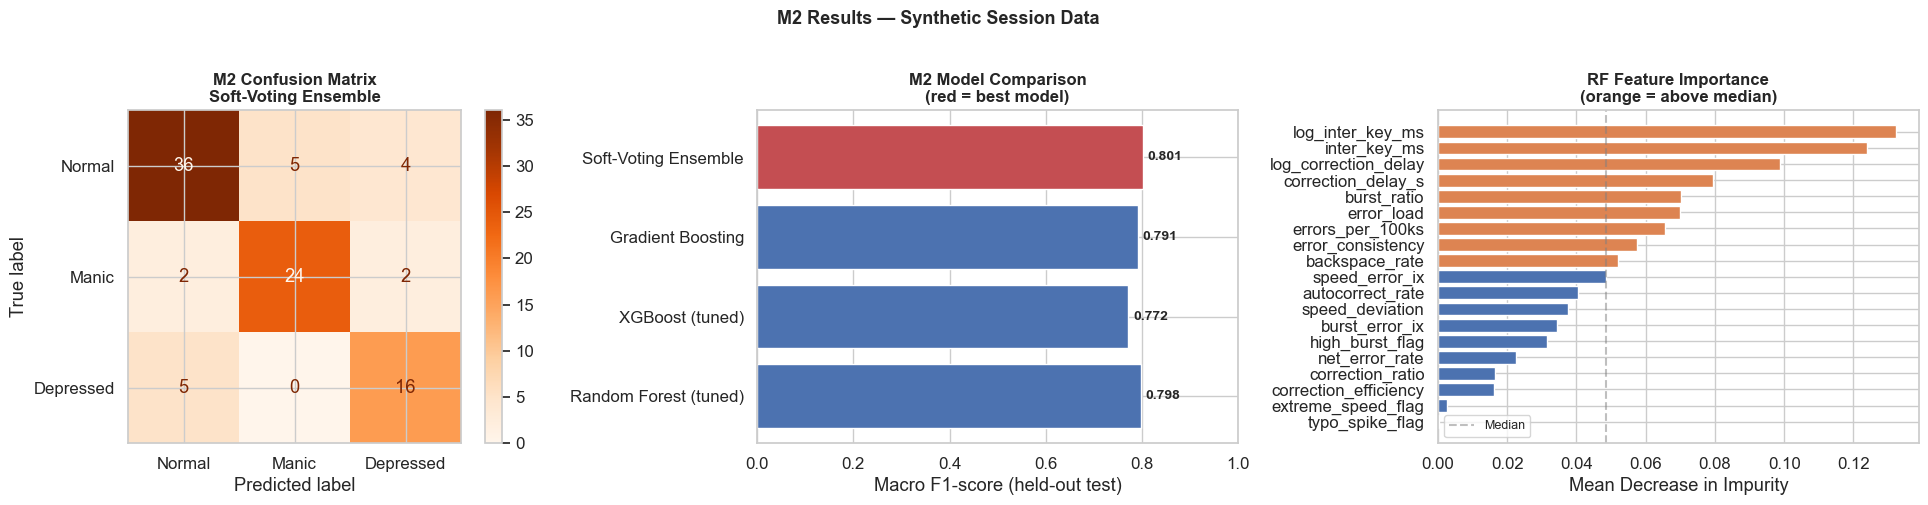

In [74]:
# ── M2 evaluation plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Best-model confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y2_te, rf.predict(X2_te),
    display_labels=['Normal', 'Manic', 'Depressed'],
    cmap='Oranges', ax=axes[0]
)
axes[0].set_title(f'M2 Confusion Matrix\n{best_m2_name}',
                  fontsize=12, fontweight='bold')

# 2. Model comparison bar chart
model_names  = list(all_m2_models.keys())
model_f1s    = [f1_score(y2_te, all_m2_models[n].predict(X2_te), average='macro')
                for n in model_names]
bar_colors   = ['#C44E52' if n == best_m2_name else '#4C72B0' for n in model_names]
bars = axes[1].barh(model_names, model_f1s, color=bar_colors, edgecolor='white')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Macro F1-score (held-out test)')
axes[1].set_title('M2 Model Comparison\n(red = best model)', fontsize=12, fontweight='bold')
for bar, v in zip(bars, model_f1s):
    axes[1].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=10, fontweight='bold')

# 3. Feature importance from the RF sub-model (or RF if ensemble not used)
rf_sub = rf.estimators_[0] if hasattr(rf, 'estimators_') else rf
if hasattr(rf_sub, 'feature_importances_'):
    fi = pd.DataFrame({'feature': M2_FEAT_COLS,
                       'importance': rf_sub.feature_importances_}).sort_values('importance')
else:
    # Fall back to RF member of ensemble
    rf_member = next((e for name, e in rf.estimators if name == 'rf'), None)
    fi = pd.DataFrame({'feature': M2_FEAT_COLS,
                       'importance': rf_member.feature_importances_}).sort_values('importance')

fi_colors = ['#DD8452' if i > fi['importance'].median() else '#4C72B0'
             for i in fi['importance']]
axes[2].barh(fi['feature'], fi['importance'], color=fi_colors, edgecolor='white')
axes[2].axvline(fi['importance'].median(), ls='--', color='grey', alpha=0.5, label='Median')
axes[2].set_xlabel('Mean Decrease in Impurity')
axes[2].set_title('RF Feature Importance\n(orange = above median)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('M2 Results — Synthetic Session Data', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 7. Model Evaluation Summary <a id='7'></a>

In [75]:
# ── Classification reports ─────────────────────────────────────────────────────
# Single-split test F1 is noisy at n=51. Report cross-validated mean ± std as
# the headline metric and treat the test-split number as a sanity check on a
# held-out slice. With ~13 test subjects, ±1 misclassification ≈ ±0.05 F1.
#
#   precision : of sessions the model labelled X, how many were X?
#   recall    : of real class-X sessions, how many did the model catch?
#   f1-score  : harmonic mean of precision & recall
#   support   : how many test sessions belonged to this class
# ─────────────────────────────────────────────────────────────────────────────

print('═' * 60)
print('  M3 — KNN on Buffalo Timing Features')
print('  Data source: REAL CMU/Buffalo keystroke dataset')
print('  Labels: motor-speed proxies (not clinical diagnoses)')
print('═' * 60)
print(classification_report(y3_te, best_knn.predict(X3_te),
      target_names=['Normal', 'Manic', 'Depressed'], zero_division=0))

print()
print('═' * 60)
print('  M3 — XGBoost on Buffalo Timing Features')
print('  Data source: REAL CMU/Buffalo keystroke dataset')
print('  Labels: motor-speed proxies (not clinical diagnoses)')
print('═' * 60)
print(classification_report(y3_te, best_xgb.predict(X3_te),
      target_names=['Normal', 'Manic', 'Depressed'], zero_division=0))

m3_f1_knn = f1_score(y3_te, best_knn.predict(X3_te), average='macro')
m3_f1_xgb = f1_score(y3_te, best_xgb.predict(X3_te), average='macro')
m3_f1 = max(m3_f1_knn, m3_f1_xgb)
m2_f1 = f1_score(y2_te, rf.predict(X2_te),        average='macro')

print()
print('═' * 60)
print(f'  M2 — {best_m2_name}')
print('  Data source: SYNTHETIC session logs')
print('  Labels: simulated mood states')
print('═' * 60)
print(classification_report(y2_te, rf.predict(X2_te),
      target_names=['Normal', 'Manic', 'Depressed'], zero_division=0))

print()
print('─' * 60)
print('  SCORE INTERPRETATION GUIDE  (3-class macro F1)')
print('─' * 60)
print('  Random guess              → 0.33')
print('  Acceptable                → ≥ 0.60')
print('  Good                      → ≥ 0.70')
print('  Excellent                 → ≥ 0.80')
print('  Suspiciously high (leak?) → ≥ 0.97')
print()
print('  M3 cross-validated (train, headline metric):')
print(f'    KNN     CV F1 = {knn_cv_mean:.3f} ± {knn_cv_std:.3f}')
print(f'    XGBoost CV F1 = {xgb_cv_mean:.3f} ± {xgb_cv_std:.3f}')
print('  M3 single-split test (sanity check, ~13 subjects):')
print(f'    KNN     test F1 = {m3_f1_knn:.3f}  {"✅" if m3_f1_knn >= 0.70 else "⚠️"}')
print(f'    XGBoost test F1 = {m3_f1_xgb:.3f}  {"✅" if m3_f1_xgb >= 0.70 else "⚠️"}')
print(f'  M2 test F1        = {m2_f1:.3f}  {"✅" if m2_f1 >= 0.70 else "⚠️"}')
print('─' * 60)
print(f'  Selected M3 classifier: {best_m3_name}')
print('─' * 60)


════════════════════════════════════════════════════════════
  M3 — KNN on Buffalo Timing Features
  Data source: REAL CMU/Buffalo keystroke dataset
  Labels: motor-speed proxies (not clinical diagnoses)
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Normal       1.00      0.40      0.57         5
       Manic       0.75      1.00      0.86         3
   Depressed       0.71      1.00      0.83         5

    accuracy                           0.77        13
   macro avg       0.82      0.80      0.75        13
weighted avg       0.83      0.77      0.74        13


════════════════════════════════════════════════════════════
  M3 — XGBoost on Buffalo Timing Features
  Data source: REAL CMU/Buffalo keystroke dataset
  Labels: motor-speed proxies (not clinical diagnoses)
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Normal       0.83      

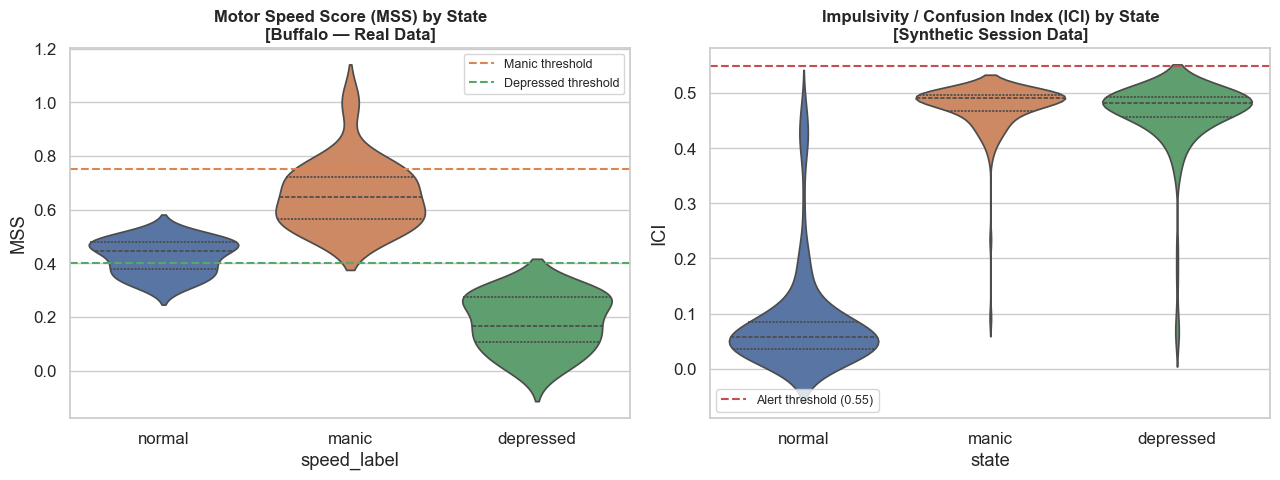

In [76]:
# ── MSS and ICI distribution by state ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# MSS — Buffalo data
sns.violinplot(data=df_timing, x='speed_label', y='MSS',
               order=['normal','manic','depressed'],
               palette=[PAL['normal'],PAL['manic'],PAL['depressed']],
               inner='quartile', ax=axes[0])
axes[0].axhline(0.75, ls='--', color=PAL['manic'],     lw=1.5, label='Manic threshold')
axes[0].axhline(0.40, ls='--', color=PAL['depressed'], lw=1.5, label='Depressed threshold')
axes[0].set_title('Motor Speed Score (MSS) by State\n[Buffalo — Real Data]',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('MSS'); axes[0].legend(fontsize=9)

# ICI — Synthetic
sns.violinplot(data=df_errors_full, x='state', y='ICI',
               order=['normal','manic','depressed'],
               palette=[PAL['normal'],PAL['manic'],PAL['depressed']],
               inner='quartile', ax=axes[1])
axes[1].axhline(0.55, ls='--', color=PAL['alert'], lw=1.5, label='Alert threshold (0.55)')
axes[1].set_title('Impulsivity / Confusion Index (ICI) by State\n[Synthetic Session Data]',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('ICI'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 8. Composite Bipolarity Score (CBS) <a id='8'></a>

The **Composite Bipolarity Score** fuses both modules into a single index:

$$
\text{CBS} = \alpha \cdot \text{MSS}_{\text{dysregulation}} + (1 - \alpha) \cdot \text{ICI}
$$

where:
- $\text{MSS}_{\text{dysregulation}} = |\text{MSS} - 0.5| \times 2$ — distance from the neutral midpoint (both extreme fast and extreme slow are dysregulated)
- $\alpha = 0.5$ by default (equal weight) — tunable by a clinical expert

| CBS range | Clinical Interpretation |
|-----------|-------------------------|
| 0.00 – 0.25 | ✅ Euthymic — no flag |
| 0.25 – 0.50 | ⚠️ Mild dysregulation |
| 0.50 – 0.70 | 🟠 Moderate — monitor closely |
| 0.70 – 1.00 | 🔴 High — clinical review recommended |

In [77]:
def compute_cbs(mss: float, ici: float, alpha: float = 0.5) -> float:
    """
    Composite Bipolarity Score (CBS).

    Parameters
    ----------
    mss   : Motor Speed Score ∈ [0,1]
    ici   : Impulsivity / Confusion Index ∈ [0,1]
    alpha : weight of MSS dysregulation component (default 0.5)

    Returns
    -------
    CBS ∈ [0,1]
    """
    mss_dysreg = abs(mss - 0.5) * 2   # 0 = perfectly normal speed, 1 = extreme
    return float(np.clip(alpha * mss_dysreg + (1 - alpha) * ici, 0, 1))


def interpret_cbs(cbs: float) -> dict:
    """Map CBS to clinical risk level."""
    if cbs < 0.25:
        return {'level': 'Euthymic',            'icon': '✅',   'color': PAL['normal']}
    elif cbs < 0.50:
        return {'level': 'Mild Dysregulation',  'icon': '⚠️',  'color': '#F5A623'}
    elif cbs < 0.70:
        return {'level': 'Moderate — Monitor',  'icon': '🟠',  'color': PAL['manic']}
    else:
        return {'level': 'High — Clinical Review','icon': '🔴', 'color': PAL['alert']}


# ── Demonstration table ───────────────────────────────────────────────────────
demo_cases = [
    ('Normal typing',          0.52, 0.12),
    ('Slightly fast, few errors', 0.68, 0.20),
    ('Very fast + many errors',   0.90, 0.65),
    ('Very slow + confused',      0.10, 0.60),
    ('Extreme manic pattern',     0.97, 0.88),
]

print(f"{'Case':<30} {'MSS':>5}  {'ICI':>5}  {'CBS':>5}  {'Risk Level'}")
print('-' * 75)
for case, mss_v, ici_v in demo_cases:
    cbs_v  = compute_cbs(mss_v, ici_v)
    interp = interpret_cbs(cbs_v)
    print(f"{case:<30} {mss_v:>5.2f}  {ici_v:>5.2f}  {cbs_v:>5.3f}  {interp['icon']} {interp['level']}")

Case                             MSS    ICI    CBS  Risk Level
---------------------------------------------------------------------------
Normal typing                   0.52   0.12  0.080  ✅ Euthymic
Slightly fast, few errors       0.68   0.20  0.280  ⚠️ Mild Dysregulation
Very fast + many errors         0.90   0.65  0.725  🔴 High — Clinical Review
Very slow + confused            0.10   0.60  0.700  🔴 High — Clinical Review
Extreme manic pattern           0.97   0.88  0.910  🔴 High — Clinical Review


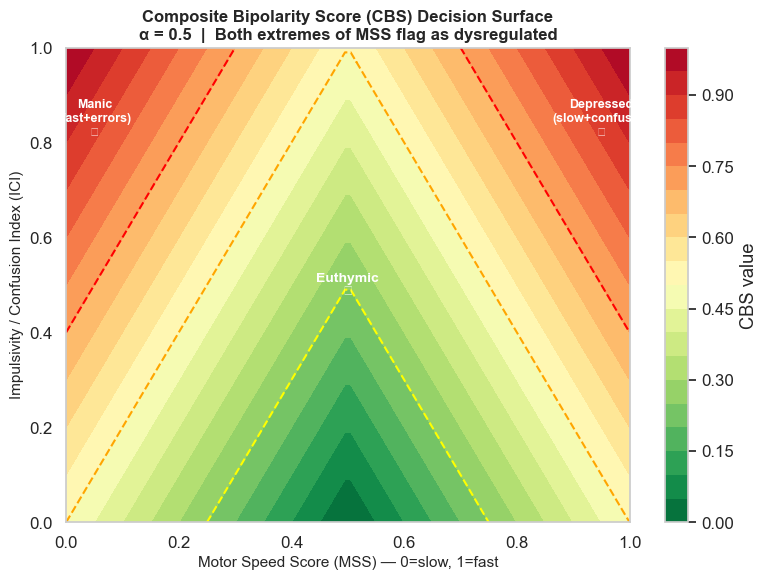

In [78]:
# ── CBS surface: MSS × ICI → CBS heatmap ─────────────────────────────────────
mss_grid = np.linspace(0, 1, 100)
ici_grid = np.linspace(0, 1, 100)
MM, II   = np.meshgrid(mss_grid, ici_grid)
CBS_grid = np.vectorize(compute_cbs)(MM, II)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.contourf(MM, II, CBS_grid, levels=20, cmap='RdYlGn_r')
plt.colorbar(im, ax=ax, label='CBS value')

# Risk zone boundaries
ax.contour(MM, II, CBS_grid, levels=[0.25, 0.50, 0.70],
           colors=['yellow','orange','red'], linewidths=1.5, linestyles='--')

# Annotate clinical zones
ax.text(0.5, 0.5, 'Euthymic\n✅', ha='center', va='center',
        fontsize=10, color='white', fontweight='bold')
ax.text(0.05, 0.85, 'Manic\n(fast+errors)\n🔴', ha='center', va='center',
        fontsize=9, color='white', fontweight='bold')
ax.text(0.95, 0.85, 'Depressed\n(slow+confused)\n🔴', ha='center', va='center',
        fontsize=9, color='white', fontweight='bold')

ax.set_xlabel('Motor Speed Score (MSS) — 0=slow, 1=fast', fontsize=11)
ax.set_ylabel('Impulsivity / Confusion Index (ICI)', fontsize=11)
ax.set_title('Composite Bipolarity Score (CBS) Decision Surface\n'
             'α = 0.5  |  Both extremes of MSS flag as dysregulated',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Longitudinal Monitoring Dashboard <a id='9'></a>

Simulating a **30-day patient monitoring timeline** with a realistic bipolar episode cycle:

- Days 1–8: Euthymic (normal)
- Days 9–16: Depressive episode
- Days 17–22: Recovery
- Days 23–30: Manic episode

In [79]:
def simulate_daily_session(state: str, day: int) -> dict:
    """
    Simulate one daily keyboard session and compute MSS, ICI, and CBS.
    Uses the trained models for inference.
    """
    # ── M3: timing session ────────────────────────────────────────────────────
    # Generate a mini Buffalo-style session for one subject
    speed_f = {'normal': 1.0, 'manic': 1.9, 'depressed': 0.4}[state]
    n = 50
    hold_ms   = np.abs(np.random.normal(120/speed_f, 25, n))
    flight_ms = np.abs(np.random.normal(90/speed_f,  20, n))
    dgraph_ms = np.abs(np.random.normal(210/speed_f, 35, n))

    # Feature order MUST match M3_FEAT_COLS (mean/median/p10/p90 flight excluded
    # to avoid label leakage; see the M3_FEAT_COLS definition cell).
    timing_vec = np.array([
        flight_ms.std(),
        np.percentile(flight_ms,75)-np.percentile(flight_ms,25),
        pd.Series(flight_ms).skew(), pd.Series(flight_ms).kurt(),
        hold_ms.mean(), hold_ms.std(),
        np.percentile(hold_ms,10), np.percentile(hold_ms,90),
        dgraph_ms.mean(), dgraph_ms.std(),
        flight_ms.std()/(flight_ms.mean()+1e-6),
        int((flight_ms<40).sum()), int((flight_ms>300).sum()),
        hold_ms.mean()/(flight_ms.mean()+1e-6),
    ]).reshape(1,-1)

    mss_day = float(np.clip(ridge_pipe.predict(timing_vec)[0], 0, 1))

    # ── M2: error session ─────────────────────────────────────────────────────
    err_sess = generate_error_sessions(state, n_sessions=1, id_offset=99000+day)
    err_sess = build_error_features(err_sess)
    err_vec  = err_sess[M2_FEAT_COLS].values
    ici_day  = float(compute_ici(rf.predict_proba(err_vec))[0])

    # ── CBS ───────────────────────────────────────────────────────────────────
    cbs_day  = compute_cbs(mss_day, ici_day)
    interp   = interpret_cbs(cbs_day)

    return {
        'day': day+1, 'true_state': state,
        'MSS': mss_day, 'ICI': ici_day, 'CBS': cbs_day,
        'risk_level': interp['level'], 'risk_color': interp['color'],
        'mean_flight_ms': flight_ms.mean(),
    }


# ── Build 30-day timeline ─────────────────────────────────────────────────────
schedule = ([('normal',8), ('depressed',8), ('normal',6), ('manic',8)])
timeline = []
day_idx  = 0
for (st, n_days) in schedule:
    for _ in range(n_days):
        timeline.append(simulate_daily_session(st, day_idx))
        day_idx += 1

df_timeline = pd.DataFrame(timeline)
df_timeline['CBS_roll'] = df_timeline['CBS'].rolling(3, min_periods=1).mean()
df_timeline['MSS_roll'] = df_timeline['MSS'].rolling(3, min_periods=1).mean()
df_timeline['ICI_roll'] = df_timeline['ICI'].rolling(3, min_periods=1).mean()
print(f'Timeline: {len(df_timeline)} days simulated.')

Timeline: 30 days simulated.


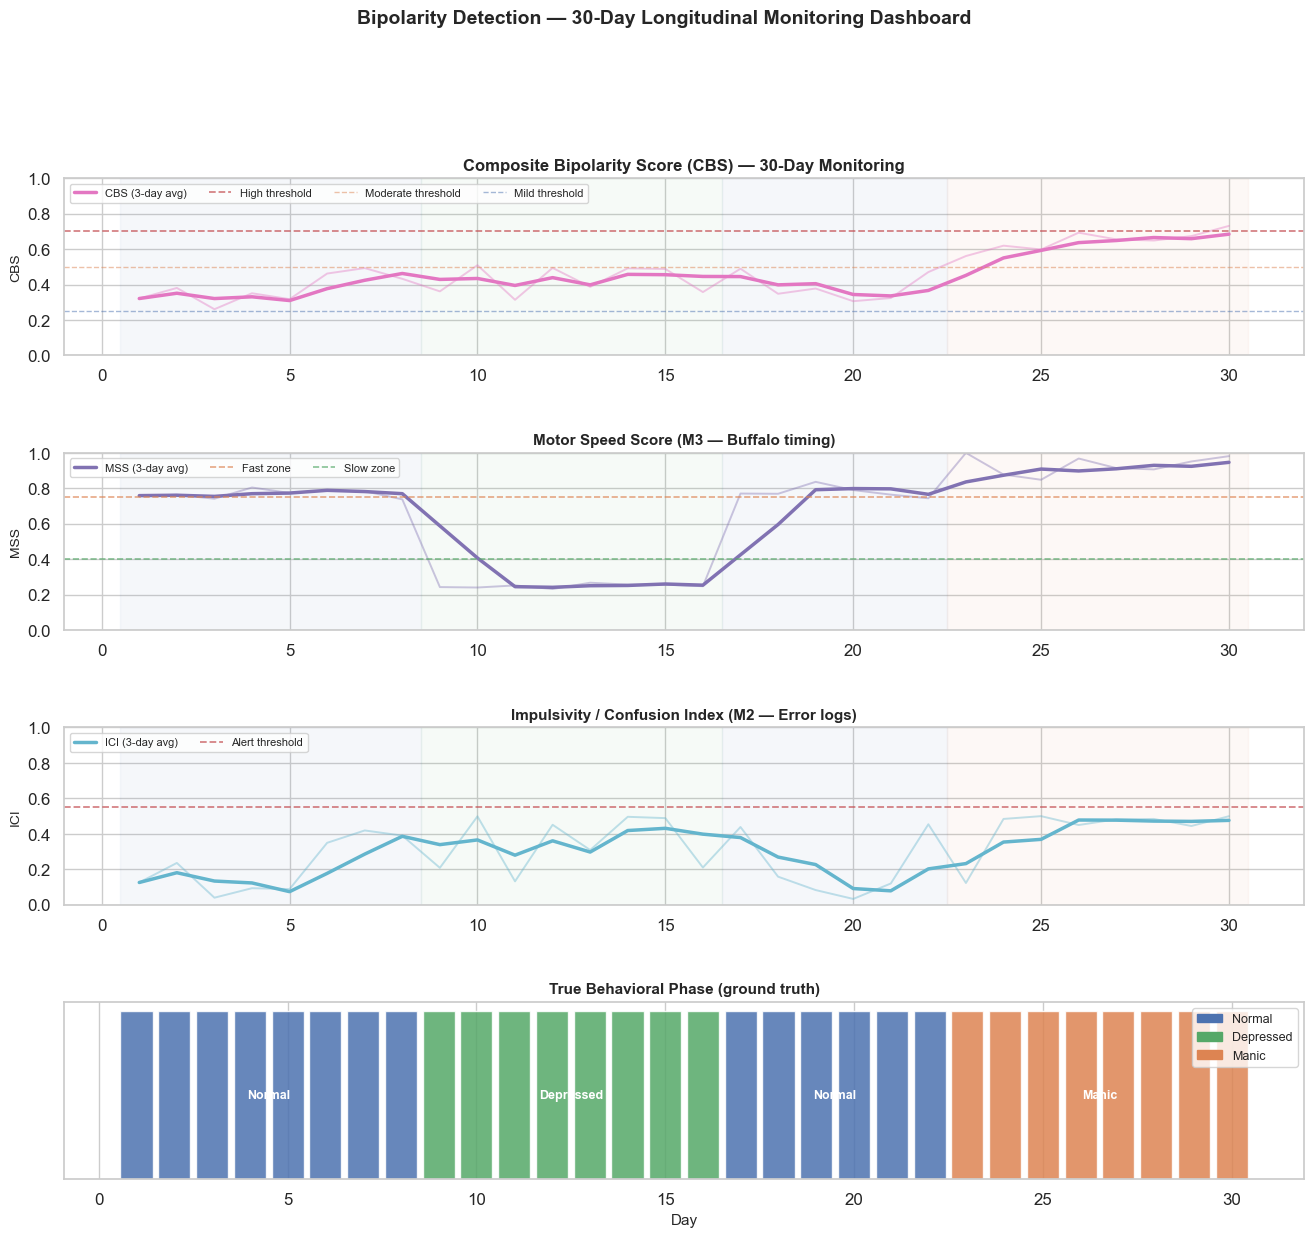

In [80]:
# ── Longitudinal dashboard ────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(4, 1, hspace=0.55)

days = df_timeline['day']
phase_bands = [(1,8,'normal'),(9,16,'depressed'),(17,22,'normal'),(23,30,'manic')]

# ── Panel 1: CBS ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(days, df_timeline['CBS'],      color=PAL['cbs'], lw=1.4, alpha=0.4)
ax1.plot(days, df_timeline['CBS_roll'], color=PAL['cbs'], lw=2.5, label='CBS (3-day avg)')
ax1.axhline(0.70, ls='--', color=PAL['alert'],  lw=1.3, alpha=0.7, label='High threshold')
ax1.axhline(0.50, ls='--', color=PAL['manic'],  lw=1.0, alpha=0.5, label='Moderate threshold')
ax1.axhline(0.25, ls='--', color=PAL['normal'], lw=1.0, alpha=0.5, label='Mild threshold')
ax1.fill_between(days, 0.70, df_timeline['CBS_roll'].clip(upper=1),
                 where=df_timeline['CBS_roll']>0.70, color=PAL['alert'], alpha=0.2)
ax1.set_ylim(0,1); ax1.set_ylabel('CBS', fontsize=10)
ax1.set_title('Composite Bipolarity Score (CBS) — 30-Day Monitoring',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left', ncol=4)
for s, e, st in phase_bands:
    ax1.axvspan(s-0.5, e+0.5, alpha=0.05, color=PAL[st])

# ── Panel 2: MSS ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(days, df_timeline['MSS'],      color=PAL['mss'], lw=1.4, alpha=0.4)
ax2.plot(days, df_timeline['MSS_roll'], color=PAL['mss'], lw=2.5, label='MSS (3-day avg)')
ax2.axhline(0.75, ls='--', color=PAL['manic'],     lw=1.2, alpha=0.7, label='Fast zone')
ax2.axhline(0.40, ls='--', color=PAL['depressed'], lw=1.2, alpha=0.7, label='Slow zone')
ax2.set_ylim(0,1); ax2.set_ylabel('MSS', fontsize=10)
ax2.set_title('Motor Speed Score (M3 — Buffalo timing)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='upper left', ncol=3)
for s, e, st in phase_bands:
    ax2.axvspan(s-0.5, e+0.5, alpha=0.05, color=PAL[st])

# ── Panel 3: ICI ──────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(days, df_timeline['ICI'],      color=PAL['ici'], lw=1.4, alpha=0.4)
ax3.plot(days, df_timeline['ICI_roll'], color=PAL['ici'], lw=2.5, label='ICI (3-day avg)')
ax3.axhline(0.55, ls='--', color=PAL['alert'], lw=1.3, alpha=0.7, label='Alert threshold')
ax3.fill_between(days, 0.55, df_timeline['ICI_roll'].clip(upper=1),
                 where=df_timeline['ICI_roll']>0.55, color=PAL['alert'], alpha=0.2)
ax3.set_ylim(0,1); ax3.set_ylabel('ICI', fontsize=10)
ax3.set_title('Impulsivity / Confusion Index (M2 — Error logs)',
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=8, loc='upper left', ncol=2)
for s, e, st in phase_bands:
    ax3.axvspan(s-0.5, e+0.5, alpha=0.05, color=PAL[st])

# ── Panel 4: Phase labels ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[3])
colors_day = [PAL[row['true_state']] for _, row in df_timeline.iterrows()]
ax4.bar(days, 1, color=colors_day, width=0.85, edgecolor='white', alpha=0.85)
ax4.set_yticks([])
ax4.set_xlabel('Day', fontsize=11)
ax4.set_title('True Behavioral Phase (ground truth)',
              fontsize=11, fontweight='bold')
patches = [mpatches.Patch(color=PAL[s], label=s.capitalize())
           for s in ['normal','depressed','manic']]
ax4.legend(handles=patches, loc='upper right', fontsize=9)
for s, e, st in phase_bands:
    ax4.text((s+e)/2, 0.5, st.capitalize(), ha='center', va='center',
             color='white', fontsize=9, fontweight='bold')

plt.suptitle('Bipolarity Detection — 30-Day Longitudinal Monitoring Dashboard',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('longitudinal_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Inference Pipeline <a id='10'></a>

Full end-to-end inference for a new anonymized keyboard session.

In [81]:
def full_inference(
    timing_vec: np.ndarray,   # shape (1, 14) — M3 features (post-leakage-fix)
    error_vec:  np.ndarray,   # shape (1, 10) — M2 features
    alpha: float = 0.5,
    label: str   = 'New session',
) -> None:
    """
    Full bipolarity inference from a single keyboard session.

    Parameters
    ----------
    timing_vec : M3 timing feature vector (14 features, matches M3_FEAT_COLS)
    error_vec  : M2 error feature vector  (10 features)
    alpha      : CBS weight for MSS component
    label      : description label for the report
    """
    # M3 -> MSS + classifier
    mss      = float(np.clip(ridge_pipe.predict(timing_vec)[0], 0, 1))
    m3_pred  = best_m3_cls.predict(timing_vec)[0]
    m3_prob  = best_m3_cls.predict_proba(timing_vec)[0]

    # M2 -> ICI
    rf_prob  = rf.predict_proba(error_vec)[0]
    ici      = float(compute_ici(rf_prob.reshape(1,-1))[0])
    rf_pred  = rf.predict(error_vec)[0]

    # CBS
    cbs      = compute_cbs(mss, ici, alpha)
    interp   = interpret_cbs(cbs)

    print('\n' + '='*58)
    print(f'   BIPOLARITY INFERENCE REPORT - {label}')
    print('='*58)
    print(f'  {'-'*54}')
    print(f'  MODULE 3 - Tapping Speed (Buffalo / Real Data)')
    print(f'  {'-'*54}')
    print(f'  {best_m3_name} predicted state : {["Normal","Manic","Depressed"][m3_pred]}')
    print(f'  P(Normal / Manic / Depressed) : {m3_prob[0]:.3f} / {m3_prob[1]:.3f} / {m3_prob[2]:.3f}')
    print(f'  Motor Speed Score   : {mss:.3f}')
    print(f'  {'-'*54}')
    print(f'  MODULE 2 - Typing Precision (Synthetic Session Data)')
    print(f'  {'-'*54}')
    print(f'  RF predicted state  : {["Normal","Manic","Depressed"][rf_pred]}')
    print(f'  P(Normal / Manic / Depressed) : {rf_prob[0]:.3f} / {rf_prob[1]:.3f} / {rf_prob[2]:.3f}')
    print(f'  ICI                 : {ici:.3f}')
    print(f'  {'-'*54}')
    print(f'  COMPOSITE BIPOLARITY SCORE (a={alpha})')
    print(f'  {'-'*54}')
    print(f'  CBS                 : {cbs:.3f}')
    print(f'  Risk level          : {interp["icon"]}  {interp["level"]}')
    print('='*58)


# ── Simulate inference for 3 different patients ───────────────────────────────
for test_state in ['normal', 'manic', 'depressed']:
    rec = simulate_daily_session(test_state, day=0)

    # Rebuild feature vectors. Order MUST match M3_FEAT_COLS — mean/median/p10/p90
    # of flight are excluded to avoid label leakage on the proxy speed_label.
    speed_f  = {'normal': 1.0, 'manic': 1.9, 'depressed': 0.4}[test_state]
    n = 50
    fl  = np.abs(np.random.normal(90/speed_f, 20, n))
    ht  = np.abs(np.random.normal(120/speed_f,25, n))
    dg  = np.abs(np.random.normal(210/speed_f,35, n))
    t_vec = np.array([
        fl.std(),
        np.percentile(fl,75)-np.percentile(fl,25),
        pd.Series(fl).skew(), pd.Series(fl).kurt(),
        ht.mean(), ht.std(), np.percentile(ht,10), np.percentile(ht,90),
        dg.mean(), dg.std(),
        fl.std()/(fl.mean()+1e-6), int((fl<40).sum()), int((fl>300).sum()),
        ht.mean()/(fl.mean()+1e-6),
    ]).reshape(1,-1)

    e_sess = generate_error_sessions(test_state, n_sessions=1, id_offset=88888)
    e_sess = build_error_features(e_sess)
    e_vec  = e_sess[M2_FEAT_COLS].values

    full_inference(t_vec, e_vec, label=f'Simulated {test_state.capitalize()} Patient')


   BIPOLARITY INFERENCE REPORT - Simulated Normal Patient
  ------------------------------------------------------
  MODULE 3 - Tapping Speed (Buffalo / Real Data)
  ------------------------------------------------------
  XGBoost predicted state : Manic
  P(Normal / Manic / Depressed) : 0.040 / 0.933 / 0.027
  Motor Speed Score   : 0.779
  ------------------------------------------------------
  MODULE 2 - Typing Precision (Synthetic Session Data)
  ------------------------------------------------------
  RF predicted state  : Normal
  P(Normal / Manic / Depressed) : 0.833 / 0.066 / 0.101
  ICI                 : 0.083
  ------------------------------------------------------
  COMPOSITE BIPOLARITY SCORE (a=0.5)
  ------------------------------------------------------
  CBS                 : 0.320
  Risk level          : ⚠️  Mild Dysregulation

   BIPOLARITY INFERENCE REPORT - Simulated Manic Patient
  ------------------------------------------------------
  MODULE 3 - Tapping Speed (B

---
## 11. Deep Learning Baseline (MLP) <a id='11'></a>

This section adds a compact tabular neural-network baseline using **MLP** for both modules.

Why MLP here:
- Data is tabular (engineered features), so a dense feed-forward model is the most appropriate DL baseline.
- It provides a fair comparison against classical models (KNN, Ridge, Random Forest).

Evaluation policy:
- Use the same train/test splits already created above.
- Compare with existing baselines on identical metrics:
  - M2 classification: macro F1
  - M3 classification: macro F1
  - M3 regression (MSS): R2 and MAE

Clinical caveat:
- M2 uses synthetic labels and M3 uses proxy labels, so DL results are benchmarking signals, not clinical proof.

Tuning MLP models with GridSearchCV...

M2 classification (macro F1):
  Random Forest baseline : 0.801
  Tuned MLP              : 0.774
  Best CV F1 (MLP)       : 0.761
  Best MLP params        : {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (16,), 'mlp__solver': 'adam'}

M2 tuned MLP classification report:
              precision    recall  f1-score   support

      Normal       0.86      0.69      0.77        45
       Manic       0.78      0.89      0.83        28
   Depressed       0.65      0.81      0.72        21

    accuracy                           0.78        94
   macro avg       0.77      0.80      0.77        94
weighted avg       0.79      0.78      0.78        94


M3 classification (macro F1):
  KNN baseline           : 0.754
  XGBoost baseline       : 0.933
  Tuned MLP              : 0.775
  Best CV F1 (MLP)       : 0.919
  Best MLP params        : {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__solver': 'adam'}
  Best classical model   : XGBoost

M

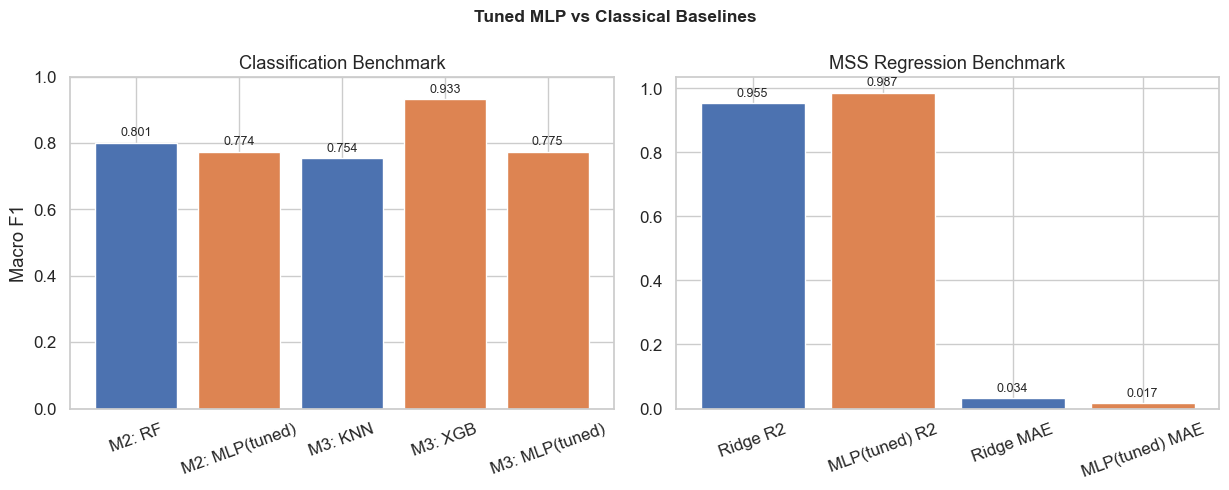


Recommendation:
  Classical models remain stronger for M3 on current data (XGBoost best).
  Keep classical for M3 and treat MLP as an auxiliary benchmark.


In [82]:
# -- Tuned MLP benchmark (tabular deep learning baseline) -----------------------
print('Tuning MLP models with GridSearchCV...')

# Common hyperparameter grids (kept compact to remain notebook-friendly).
cls_param_grid = {
    'mlp__hidden_layer_sizes': [(16,), (32,), (64, 32)],
    'mlp__alpha': [1e-4, 1e-3, 1e-2],
    'mlp__solver': ['adam', 'lbfgs'],
}

# For regression on very small M3 data, we prioritize MAE stability and smaller nets.
reg_param_grid = [
    {
        'mlp__solver': ['lbfgs'],
        'mlp__activation': ['tanh', 'relu'],
        'mlp__hidden_layer_sizes': [(4,), (8,), (16,), (8, 4)],
        'mlp__alpha': [1e-4, 1e-3, 1e-2, 1e-1],
    },
    {
        'mlp__solver': ['adam'],
        'mlp__activation': ['tanh', 'relu'],
        'mlp__hidden_layer_sizes': [(4,), (8,), (16,), (8, 4)],
        'mlp__alpha': [1e-4, 1e-3, 1e-2],
        'mlp__learning_rate_init': [1e-3, 5e-4],
        'mlp__early_stopping': [True],
    },
]
# -- M2: tuned MLP classifier ----------------------------------------------------
mlp_m2_base = Pipeline([
    ('sc', StandardScaler()),
    ('mlp', MLPClassifier(
        activation='relu',
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

gs_m2 = GridSearchCV(
    estimator=mlp_m2_base,
    param_grid=cls_param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    refit=True
)
gs_m2.fit(X2_tr, y2_tr)
best_mlp_m2 = gs_m2.best_estimator_
y2_pred_mlp = best_mlp_m2.predict(X2_te)
f1_m2_mlp = f1_score(y2_te, y2_pred_mlp, average='macro')
f1_m2_rf = f1_score(y2_te, rf.predict(X2_te), average='macro')

print('\nM2 classification (macro F1):')
print(f'  Random Forest baseline : {f1_m2_rf:.3f}')
print(f'  Tuned MLP              : {f1_m2_mlp:.3f}')
print(f'  Best CV F1 (MLP)       : {gs_m2.best_score_:.3f}')
print(f'  Best MLP params        : {gs_m2.best_params_}')
print()
print('M2 tuned MLP classification report:')
print(classification_report(y2_te, y2_pred_mlp, target_names=['Normal', 'Manic', 'Depressed']))

# -- M3: tuned MLP classifier ----------------------------------------------------
mlp_m3_cls_base = Pipeline([
    ('sc', StandardScaler()),
    ('mlp', MLPClassifier(
        activation='relu',
        max_iter=4000,
        random_state=RANDOM_STATE
    ))
])

gs_m3_cls = GridSearchCV(
    estimator=mlp_m3_cls_base,
    param_grid=cls_param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    refit=True
)
gs_m3_cls.fit(X3_tr, y3_tr)
best_mlp_m3_cls = gs_m3_cls.best_estimator_
y3_pred_mlp = best_mlp_m3_cls.predict(X3_te)
f1_m3_mlp = f1_score(y3_te, y3_pred_mlp, average='macro')
f1_m3_knn = f1_score(y3_te, best_knn.predict(X3_te), average='macro')
f1_m3_xgb = f1_score(y3_te, best_xgb.predict(X3_te), average='macro')
m3_classical_best = max(f1_m3_knn, f1_m3_xgb)
m3_classical_name = 'KNN' if f1_m3_knn >= f1_m3_xgb else 'XGBoost'

print('\nM3 classification (macro F1):')
print(f'  KNN baseline           : {f1_m3_knn:.3f}')
print(f'  XGBoost baseline       : {f1_m3_xgb:.3f}')
print(f'  Tuned MLP              : {f1_m3_mlp:.3f}')
print(f'  Best CV F1 (MLP)       : {gs_m3_cls.best_score_:.3f}')
print(f'  Best MLP params        : {gs_m3_cls.best_params_}')
print(f'  Best classical model   : {m3_classical_name}')
print()
print('M3 tuned MLP classification report:')
print(classification_report(y3_te, y3_pred_mlp, target_names=['Normal', 'Manic', 'Depressed']))

# -- M3: tuned MLP regressor (MSS) ----------------------------------------------
mlp_m3_reg_base = Pipeline([
    ('sc', StandardScaler()),
    ('mlp', MLPRegressor(
        max_iter=6000,
        random_state=RANDOM_STATE
    ))
])

gs_m3_reg = GridSearchCV(
    estimator=mlp_m3_reg_base,
    param_grid=reg_param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    refit=True
)
gs_m3_reg.fit(X3_reg_tr, y3_reg_tr)
best_mlp_m3_reg = gs_m3_reg.best_estimator_
mss_pred_mlp = np.clip(best_mlp_m3_reg.predict(X3_reg_te), 0, 1)

r2_mlp = r2_score(y3_reg_te, mss_pred_mlp)
mae_mlp = mean_absolute_error(y3_reg_te, mss_pred_mlp)
r2_ridge = r2_score(y3_reg_te, mss_pred_te)
mae_ridge = mean_absolute_error(y3_reg_te, mss_pred_te)
best_cv_mae = -gs_m3_reg.best_score_

print('\nM3 regression (MSS):')
print(f'  Ridge baseline         : R2={r2_ridge:.3f}, MAE={mae_ridge:.4f}')
print(f'  Tuned MLP              : R2={r2_mlp:.3f}, MAE={mae_mlp:.4f}')
print(f'  Best CV MAE (MLP)      : {best_cv_mae:.4f}')
print(f'  Best MLP params        : {gs_m3_reg.best_params_}')

# -- Compact comparison plots ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

# Classification comparison (macro F1).
cls_labels = ['M2: RF', 'M2: MLP(tuned)', 'M3: KNN', 'M3: XGB', 'M3: MLP(tuned)']
cls_vals = [f1_m2_rf, f1_m2_mlp, f1_m3_knn, f1_m3_xgb, f1_m3_mlp]
cls_cols = [PAL['normal'], PAL['manic'], PAL['normal'], PAL['manic'], PAL['manic']]
axes[0].bar(cls_labels, cls_vals, color=cls_cols, edgecolor='white')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Classification Benchmark')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(cls_vals):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# Regression comparison (R2 and MAE).
reg_labels = ['Ridge R2', 'MLP(tuned) R2', 'Ridge MAE', 'MLP(tuned) MAE']
reg_vals = [r2_ridge, r2_mlp, mae_ridge, mae_mlp]
reg_cols = [PAL['normal'], PAL['manic'], PAL['normal'], PAL['manic']]
axes[1].bar(reg_labels, reg_vals, color=reg_cols, edgecolor='white')
axes[1].set_title('MSS Regression Benchmark')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(reg_vals):
    offset = 0.02 if v >= 0 else -0.06
    axes[1].text(i, v + offset, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Tuned MLP vs Classical Baselines', fontsize=12.5, fontweight='bold')
plt.tight_layout()
plt.show()

# -- Recommendation block --------------------------------------------------------
print('\nRecommendation:')
if (f1_m3_mlp >= m3_classical_best) and (r2_mlp >= r2_ridge) and (mae_mlp <= mae_ridge):
    print('  Tuned MLP is competitive on M3. You can keep DL as co-primary for M3.')
elif f1_m3_mlp >= m3_classical_best:
    print('  Tuned MLP improves M3 classification but not MSS regression.')
    print('  Keep MLP for class prediction (Normal/Manic/Depressed) as auxiliary + report Ridge for MSS.')
else:
    print(f'  Classical models remain stronger for M3 on current data ({m3_classical_name} best).')
    print('  Keep classical for M3 and treat MLP as an auxiliary benchmark.')

Running robustness checks for M2...

A) Permutation test (label shuffling):
   Observed CV F1      : 0.768
   Permutation mean F1 : 0.328
   p-value             : 0.0050

B) Hard-overlap stress test (synthetic):
   Holdout macro-F1    : 0.693
   Repeated CV mean±std: 0.693 ± 0.048


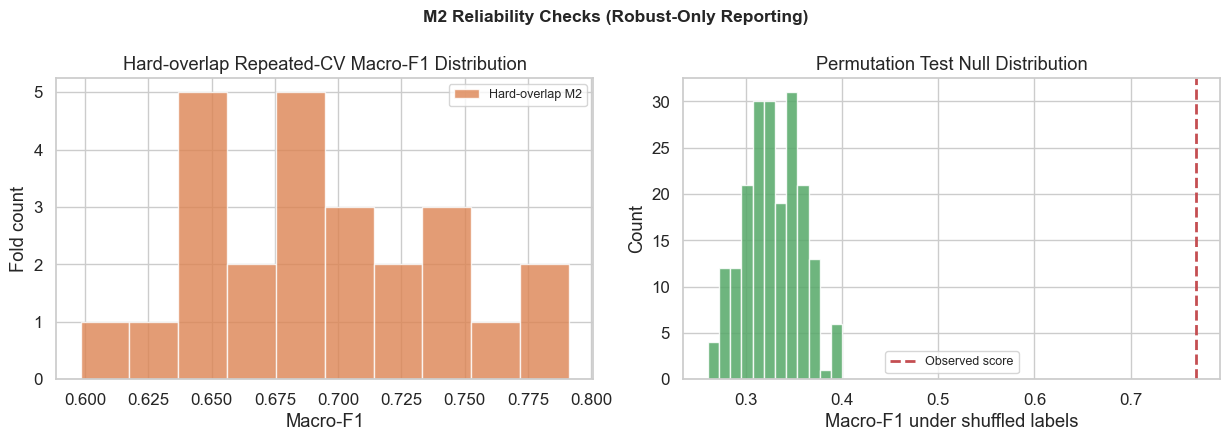


Interpretation aid:
  The model captures signal beyond chance (very low permutation p-value).
  Perfect scores are not robust when class overlap increases -> treat 1.00 as optimistic.


In [83]:
# -- 11.1 Robust validation for M2 perfect scores -------------------------------
from sklearn.model_selection import RepeatedStratifiedKFold, permutation_test_score
from sklearn.base import clone

print('Running robustness checks for M2...')

# A) Permutation test to assess whether high score could occur by chance.
perm_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
perm_score, perm_scores, perm_p = permutation_test_score(
    estimator=clone(rf),
    # FIXED: Use training data only
    X=X2_tr,
    y=y2_tr,
    scoring='f1_macro',
    cv=perm_cv,
    n_permutations=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('\nA) Permutation test (label shuffling):')
print(f'   Observed CV F1      : {perm_score:.3f}')
print(f'   Permutation mean F1 : {perm_scores.mean():.3f}')
print(f'   p-value             : {perm_p:.4f}')

# B) Stress test with intentionally harder synthetic overlap.
feat_df = df2_tr[M2_FEAT_COLS + ['label']].copy()
global_mu = feat_df[M2_FEAT_COLS].mean()
global_sd = feat_df[M2_FEAT_COLS].std().replace(0, 1e-3)

hard_frames = []
n_per_class = 120

for cls in sorted(feat_df['label'].unique()):
    cls_df = feat_df[feat_df['label'] == cls]
    mu_cls = cls_df[M2_FEAT_COLS].mean()
    sd_cls = cls_df[M2_FEAT_COLS].std().replace(0, 1e-3)

    # Blend class means toward global mean and inflate variance to force overlap.
    mu_hard = 0.55 * mu_cls + 0.45 * global_mu
    sd_hard = 1.80 * sd_cls + 0.20 * global_sd

    Xh = np.random.normal(
        loc=mu_hard.values,
        scale=sd_hard.values,
        size=(n_per_class, len(M2_FEAT_COLS))
    )

    hard_cls = pd.DataFrame(Xh, columns=M2_FEAT_COLS)
    hard_cls['label'] = int(cls)
    hard_frames.append(hard_cls)

df_hard = pd.concat(hard_frames, ignore_index=True)

# Domain-aware clipping/rounding for plausibility.
clip_01 = ['backspace_rate', 'autocorrect_rate', 'net_error_rate', 'burst_ratio',
           'correction_efficiency', 'correction_ratio']
for c in clip_01:
    df_hard[c] = df_hard[c].clip(0, 1)

df_hard['error_load'] = df_hard['error_load'].clip(0, 2)
df_hard['correction_delay_s'] = df_hard['correction_delay_s'].clip(lower=0)
df_hard['inter_key_ms'] = df_hard['inter_key_ms'].clip(lower=20)
df_hard['typo_spike_flag'] = (df_hard['typo_spike_flag'] > 0.5).astype(int)

X2_hard = df_hard[M2_FEAT_COLS].values
y2_hard = df_hard['label'].astype(int).values

Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(
    X2_hard, y2_hard, test_size=0.2, stratify=y2_hard, random_state=RANDOM_STATE
)

rf_hard = clone(rf)
rf_hard.fit(Xh_tr, yh_tr)
f1_hard_holdout = f1_score(yh_te, rf_hard.predict(Xh_te), average='macro')

hard_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
hard_rep_scores = cross_val_score(
    clone(rf), X2_hard, y2_hard, cv=hard_cv, scoring='f1_macro', n_jobs=-1
)

print('\nB) Hard-overlap stress test (synthetic):')
print(f'   Holdout macro-F1    : {f1_hard_holdout:.3f}')
print(f'   Repeated CV mean±std: {hard_rep_scores.mean():.3f} ± {hard_rep_scores.std():.3f}')

# Compact visual summary.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

axes[0].hist(hard_rep_scores, bins=10, alpha=0.8, color=PAL['manic'], edgecolor='white', label='Hard-overlap M2')
axes[0].set_title('Hard-overlap Repeated-CV Macro-F1 Distribution')
axes[0].set_xlabel('Macro-F1')
axes[0].set_ylabel('Fold count')
axes[0].legend(fontsize=9)

axes[1].hist(perm_scores, bins=12, alpha=0.85, color=PAL['depressed'], edgecolor='white')
axes[1].axvline(perm_score, color=PAL['alert'], linestyle='--', linewidth=2, label='Observed score')
axes[1].set_title('Permutation Test Null Distribution')
axes[1].set_xlabel('Macro-F1 under shuffled labels')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

plt.suptitle('M2 Reliability Checks (Robust-Only Reporting)', fontsize=12.5, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretation aid:')
if perm_p < 0.01:
    print('  The model captures signal beyond chance (very low permutation p-value).')
else:
    print('  The model may not be clearly better than chance under this setup.')

if hard_rep_scores.mean() < 0.90:
    print('  Perfect scores are not robust when class overlap increases -> treat 1.00 as optimistic.')
else:
    print('  Scores remain high even under harder overlap -> synthetic generator still easy/separable.')

---
## 11.2 Final Hybrid Inference Pipeline (Best-Per-Task)

This section locks in the strongest model per sub-task based on observed benchmarks:

- **M2 classification + ICI**: Random Forest (`rf`)
- **M3 classification**: Tuned MLP (`best_mlp_m3_cls`) if available, else best classical (`best_m3_cls`, KNN or XGBoost by CV)
- **M3 regression (MSS)**: Ridge (`ridge_pipe`)

This gives a single production-style inference function while preserving the best behavior of each module.

In [84]:
# -- 11.2 Hybrid inference: choose best model per task ---------------------------
def _simulate_feature_vectors_for_state(state: str, n: int = 50):
    """Create one synthetic timing/error feature pair for demonstration."""
    speed_f = {'normal': 1.0, 'manic': 1.9, 'depressed': 0.4}[state]

    # M3 timing vector (14 features, same order as M3_FEAT_COLS).
    # mean/median/p10/p90 of flight are excluded to avoid label leakage on the
    # proxy speed_label (a deterministic threshold on mean_flight).
    fl = np.abs(np.random.normal(90 / speed_f, 20, n))
    ht = np.abs(np.random.normal(120 / speed_f, 25, n))
    dg = np.abs(np.random.normal(210 / speed_f, 35, n))
    timing_vec = np.array([
        fl.std(),
        np.percentile(fl, 75) - np.percentile(fl, 25),
        pd.Series(fl).skew(), pd.Series(fl).kurt(),
        ht.mean(), ht.std(), np.percentile(ht, 10), np.percentile(ht, 90),
        dg.mean(), dg.std(),
        fl.std() / (fl.mean() + 1e-6), int((fl < 40).sum()), int((fl > 300).sum()),
        ht.mean() / (fl.mean() + 1e-6),
    ]).reshape(1, -1)

    # M2 error vector (10 features, same order as M2_FEAT_COLS)
    err_sess = generate_error_sessions(state, n_sessions=1, id_offset=77777)
    err_sess = build_error_features(err_sess)
    error_vec = err_sess[M2_FEAT_COLS].values

    return timing_vec, error_vec


def full_inference_hybrid(
    timing_vec: np.ndarray,   # shape (1, 14)
    error_vec: np.ndarray,    # shape (1, 10)
    alpha: float = 0.5,
    label: str = 'New session',
) -> dict:
    """Hybrid final inference using the best model per task from benchmarking."""
    label_names = ['Normal', 'Manic', 'Depressed']

    # M3 classification model: prefer tuned MLP, fallback to best classical M3.
    if 'best_mlp_m3_cls' in globals():
        m3_cls_model = best_mlp_m3_cls
        m3_cls_name = 'Tuned MLP'
    else:
        m3_cls_model = best_m3_cls
        m3_cls_name = f'{best_m3_name} (best classical)'

    # Final per-task model choices
    m2_cls_model = rf
    m3_reg_model = ridge_pipe

    # M3 outputs
    m3_pred = int(m3_cls_model.predict(timing_vec)[0])
    m3_prob = m3_cls_model.predict_proba(timing_vec)[0]
    mss = float(np.clip(m3_reg_model.predict(timing_vec)[0], 0, 1))

    # M2 outputs
    m2_pred = int(m2_cls_model.predict(error_vec)[0])
    m2_prob = m2_cls_model.predict_proba(error_vec)[0]
    ici = float(compute_ici(m2_prob.reshape(1, -1))[0])

    # Fused output
    cbs = compute_cbs(mss, ici, alpha=alpha)
    interp = interpret_cbs(cbs)

    print('\n' + '=' * 66)
    print(f' HYBRID BIPOLARITY INFERENCE REPORT - {label}')
    print('=' * 66)
    print(' M3 Classification model :', m3_cls_name)
    print(' M3 Regression model     : Ridge')
    print(' M2 Classification model : Random Forest')
    print('-' * 66)
    print(f' M3 predicted class      : {label_names[m3_pred]}')
    print(f' M3 probabilities        : N={m3_prob[0]:.3f} | M={m3_prob[1]:.3f} | D={m3_prob[2]:.3f}')
    print(f' MSS (Ridge)             : {mss:.3f}')
    print('-' * 66)
    print(f' M2 predicted class      : {label_names[m2_pred]}')
    print(f' M2 probabilities        : N={m2_prob[0]:.3f} | M={m2_prob[1]:.3f} | D={m2_prob[2]:.3f}')
    print(f' ICI (RF-derived)        : {ici:.3f}')
    print('-' * 66)
    print(f' CBS (alpha={alpha:.2f})          : {cbs:.3f}')
    print(f' Risk level              : {interp["icon"]} {interp["level"]}')
    print('=' * 66)

    return {
        'm3_class_model': m3_cls_name,
        'm3_pred_class': label_names[m3_pred],
        'm2_pred_class': label_names[m2_pred],
        'MSS': mss,
        'ICI': ici,
        'CBS': cbs,
        'risk_level': interp['level'],
    }


# Demo on three synthetic profiles.
for st in ['normal', 'manic', 'depressed']:
    t_vec, e_vec = _simulate_feature_vectors_for_state(st)
    _ = full_inference_hybrid(t_vec, e_vec, alpha=0.5, label=f'Simulated {st.capitalize()} profile')


 HYBRID BIPOLARITY INFERENCE REPORT - Simulated Normal profile
 M3 Classification model : Tuned MLP
 M3 Regression model     : Ridge
 M2 Classification model : Random Forest
------------------------------------------------------------------
 M3 predicted class      : Manic
 M3 probabilities        : N=0.001 | M=0.984 | D=0.016
 MSS (Ridge)             : 0.792
------------------------------------------------------------------
 M2 predicted class      : Normal
 M2 probabilities        : N=0.904 | M=0.008 | D=0.087
 ICI (RF-derived)        : 0.048
------------------------------------------------------------------
 CBS (alpha=0.50)          : 0.316
 Risk level              : ⚠️ Mild Dysregulation

 HYBRID BIPOLARITY INFERENCE REPORT - Simulated Manic profile
 M3 Classification model : Tuned MLP
 M3 Regression model     : Ridge
 M2 Classification model : Random Forest
------------------------------------------------------------------
 M3 predicted class      : Manic
 M3 probabilities      

---
## Summary

| Component | Dataset | Model | Output |
|-----------|---------|-------|--------|
| **M3 — Tapping Speed** | Buffalo CSV (real, 51 subjects) | KNN or XGBoost (best by CV) + Ridge | Motor Speed Score (MSS ∈ [0,1]) |
| **M2 — Precision** | Synthetic session data | Random Forest | Impulsivity/Confusion Index (ICI ∈ [0,1]) |
| **Fusion** | Both | Weighted average | Composite Bipolarity Score (CBS ∈ [0,1]) |

### CBS Risk Scale
| CBS | Level |
|-----|-------|
| < 0.25 | ✅ Euthymic |
| 0.25–0.50 | ⚠️ Mild dysregulation |
| 0.50–0.70 | 🟠 Moderate — monitor |
| > 0.70 | 🔴 High — clinical review |

---

